[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wdittaya/AI-for-digital-health-course/blob/main/lab03_supervised_unsupervised_rl.ipynb)

# Lab 3: การเรียนรู้แบบมีผู้สอน การเรียนรู้แบบไม่มีผู้สอน และการเรียนรู้แบบเสริมกำลัง (Supervised, Unsupervised & Reinforcement Learning)

**รายวิชา:** 3099704 AI for Digital Health (2026) · **คาบเรียน:** วันอังคารที่ 6 ตุลาคม 2026 · **เวลาโดยประมาณ:** 60–90 นาที

## วัตถุประสงค์การเรียนรู้

- ฝึกสอนและเปรียบเทียบตัวจำแนกประเภทแบบมีผู้สอน (supervised classifiers) ได้แก่ logistic regression, decision tree, random forest และ XGBoost
- ประยุกต์ใช้การเรียนรู้แบบไม่มีผู้สอน (unsupervised learning) ได้แก่ การจัดกลุ่มด้วย K-means และการวิเคราะห์องค์ประกอบหลัก (PCA) เพื่อจำแนกกลุ่มผู้ป่วย (patient stratification)
- อธิบายกรอบแนวคิดของการเรียนรู้แบบเสริมกำลัง (reinforcement learning, RL) ผ่านตัวอย่างนโยบายการรักษา (treatment policy) อย่างง่าย
- เลือกรูปแบบการเรียนรู้ (learning paradigm) ให้เหมาะสมกับโจทย์ทางคลินิก
- **แปลผล**สิ่งที่แต่ละโมเดลเรียนรู้ และประเมินความสมเหตุสมผลทางคลินิก

> **แนวทางการทำปฏิบัติการ** (งานเดี่ยว)
>
> ✅ **ส่วนหลัก — สำหรับผู้เรียนทุกคน ไม่จำเป็นต้องมีพื้นฐานการเขียนโปรแกรม** ให้รันเซลล์ (cell) ตามลำดับจากบนลงล่าง (คลิกปุ่ม ▶ ทางซ้ายของเซลล์ หรือใช้ **Shift+Enter**) เซลล์ ⭐ **Exercise** แต่ละเซลล์กำหนดให้แก้ไขค่าเพียงหนึ่งค่าหรือเติมโค้ดสั้น ๆ หนึ่งบรรทัด และมีเซลล์ ✅ **เฉลย** อยู่ถัดไป ผู้เรียนควรทำแบบฝึกหัดด้วยตนเองก่อน หากไม่สามารถดำเนินการต่อได้ ให้รันเซลล์เฉลยแล้วทำส่วนถัดไป จากนั้นให้ตอบคำถาม ✍️ ในเซลล์ข้อความ (ดับเบิลคลิกที่เซลล์ `✍️ คำตอบ:` เพื่อพิมพ์) ซึ่งถือเป็น**ชิ้นงานที่ต้องส่ง** คำถามมุ่งเน้นการแปลผลว่า*โมเดลพบสิ่งใด และสมเหตุสมผลทางคลินิกหรือไม่* มิใช่การเขียนโค้ด
>
> 🏆 **โจทย์ท้าทายบนตารางอันดับ — ไม่บังคับ สำหรับผู้เรียนที่เขียนโปรแกรมได้** ส่วนท้ายของโน้ตบุ๊ก (notebook) มีโจทย์ท้าทายซึ่งให้คะแนนอัตโนมัติบน[ตารางอันดับ (leaderboard) ของรายวิชาบน Hugging Face](https://huggingface.co/spaces/wdittaya/aidh-leaderboard) ส่วนนี้**ไม่บังคับ**และไม่นับเป็นชิ้นงานที่ต้องส่ง ผู้เรียนที่ประสงค์จะเข้าร่วมให้ระบุนามแฝงใน `NAME` และรหัสเข้าร่วมซึ่งผู้สอนประกาศในการเรียนการสอนผ่าน Zoom ใน `JOIN_CODE` ในเซลล์การตั้งค่าด้านล่าง
>
> ปฏิบัติการนี้ใช้ [Google Colab](https://colab.research.google.com) รุ่นไม่มีค่าใช้จ่ายได้ภายในเวลาไม่กี่นาที (ไม่จำเป็นต้องใช้ GPU) หากพบปัญหา สามารถสอบถามผู้สอนผ่านช่องแชตของ Zoom

In [ ]:
# @title ⚙️ การตั้งค่า — โปรดรันเซลล์นี้ก่อน (NAME และ JOIN_CODE ใช้เฉพาะโจทย์ท้าทายบนตารางอันดับ ซึ่งไม่บังคับ)
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   เซลล์นี้เป็นการ "เตรียมความพร้อม" ก่อนเริ่มปฏิบัติการ โดยทำ 3 อย่าง ได้แก่
#   1) ติดตั้งเครื่องมือ (ไลบรารี) เพิ่มเติมที่จำเป็นต้องใช้ใน Google Colab
#   2) กำหนดค่าพื้นฐาน เช่น รหัสปฏิบัติการ ชื่อที่จะแสดง และรหัสเข้าร่วมตารางอันดับ
#   3) สร้าง "ฟังก์ชัน" (ชุดคำสั่งสำเร็จรูปที่เรียกใช้ซ้ำได้) 2 ตัว คือ
#        - lab_data(...)              : ดาวน์โหลดไฟล์ข้อมูลของรายวิชา
#        - submit_to_leaderboard(...) : ส่งผลการทำนายไปยังตารางอันดับ (ไม่บังคับ)
#   ผู้เรียนเพียงกดรันเซลล์นี้ 1 ครั้ง ไม่จำเป็นต้องแก้ไขโค้ด
#   (ยกเว้นต้องการเข้าร่วมตารางอันดับ ให้กรอก NAME และ JOIN_CODE ด้านล่าง)
# ============================================================================

# ติดตั้งไลบรารีเพิ่มเติมลงในเครื่อง Colab
#   - เครื่องหมาย ! ด้านหน้า หมายถึงสั่งงานระบบปฏิบัติการ (ไม่ใช่คำสั่งภาษา Python)
#   - pip install : คำสั่งติดตั้งไลบรารีของ Python
#   - -q (quiet)  : ให้แสดงข้อความระหว่างติดตั้งให้น้อยที่สุด
#   - gradio_client   : ไลบรารีสำหรับติดต่อกับเว็บแอปตารางอันดับ (Hugging Face Space)
#   - huggingface_hub : ไลบรารีสำหรับดาวน์โหลดไฟล์จากเว็บไซต์ Hugging Face
!pip -q install gradio_client huggingface_hub

# สร้างตัวแปร (ช่องเก็บค่า) HF_OWNER แล้วใส่ข้อความ "wdittaya" ไว้
#   เครื่องหมาย = หมายถึง "นำค่าทางขวา ไปเก็บไว้ในชื่อทางซ้าย"
#   ข้อความในภาษา Python ต้องอยู่ในเครื่องหมายคำพูด " "
HF_OWNER  = "wdittaya"     # บัญชี Hugging Face ที่ใช้โฮสต์ตารางอันดับของรายวิชา (ผู้สอนเป็นผู้กำหนด)
# รหัสของปฏิบัติการนี้ ใช้ระบุว่าผลที่ส่งเป็นของปฏิบัติการใด (ไม่ต้องแก้ไข)
LAB_ID    = "lab03"
# ชื่อที่จะแสดงบนตารางอันดับ: พิมพ์ชื่อไว้ระหว่างเครื่องหมาย " " เช่น NAME = "หมอเอ"
NAME      = ""            # ไม่บังคับ: ชื่อที่จะแสดงบนตารางอันดับแบบสาธารณะ (สามารถใช้นามแฝงได้)
# รหัสเข้าร่วมตารางอันดับ: พิมพ์รหัสที่ผู้สอนแจ้งไว้ระหว่างเครื่องหมาย " "
JOIN_CODE = ""            # ไม่บังคับ: รหัสเข้าร่วมซึ่งผู้สอนประกาศในการเรียนการสอนผ่าน Zoom

# สร้างชื่อเว็บแอปตารางอันดับ โดยนำ HF_OWNER มาต่อกับข้อความ
#   - f"..." (f-string) คือข้อความที่แทรกค่าตัวแปรได้ โดยเขียนชื่อตัวแปรไว้ใน { }
#   - ผลลัพธ์คือ "wdittaya/aidh-leaderboard"
SPACE_ID  = f"{HF_OWNER}/aidh-leaderboard"
# สร้างชื่อคลังข้อมูล (dataset) ของรายวิชาในลักษณะเดียวกัน ผลลัพธ์คือ "wdittaya/aidh-lab-data"
DATA_REPO = f"{HF_OWNER}/aidh-lab-data"

# นำเข้า (import) ฟังก์ชัน hf_hub_download จากไลบรารี huggingface_hub
#   ฟังก์ชันนี้ใช้ดาวน์โหลดไฟล์จากเว็บไซต์ Hugging Face มาเก็บไว้ในเครื่อง
from huggingface_hub import hf_hub_download

# ----------------------------------------------------------------------------
# สร้างฟังก์ชัน lab_data สำหรับดาวน์โหลดไฟล์ข้อมูลของรายวิชา
#   - def คือคำสั่งสร้างฟังก์ชันใหม่ ตามด้วยชื่อฟังก์ชันและพารามิเตอร์ในวงเล็บ
#   - path : พารามิเตอร์ (ค่าที่ผู้ใช้ส่งเข้ามา) คือชื่อไฟล์ที่ต้องการ เช่น "pima/test_ids.csv"
#   - บรรทัดที่ย่อหน้าเข้าไปด้านล่าง คือคำสั่งที่อยู่ภายในฟังก์ชัน
# ----------------------------------------------------------------------------
def lab_data(path):
    """ดาวน์โหลดไฟล์ข้อมูลทดสอบสาธารณะของรายวิชา 1 ไฟล์ (เช่น 'pima/test_ids.csv') และคืนค่าตำแหน่งไฟล์ในเครื่อง"""
    # เรียก hf_hub_download(...) เพื่อดาวน์โหลดไฟล์ แล้วส่งตำแหน่งไฟล์ในเครื่องกลับไป (return)
    #   - DATA_REPO           : ชื่อคลังข้อมูลบน Hugging Face ที่เก็บไฟล์
    #   - path                : ชื่อไฟล์ที่ต้องการดาวน์โหลดภายในคลังข้อมูลนั้น
    #   - repo_type="dataset" : ระบุว่าคลังนี้เป็นประเภท "ชุดข้อมูล" (ไม่ใช่โมเดล)
    return hf_hub_download(DATA_REPO, path, repo_type="dataset")

# ----------------------------------------------------------------------------
# สร้างฟังก์ชัน submit_to_leaderboard สำหรับส่งไฟล์ผลการทำนายไปยังตารางอันดับ
#   - path   : ชื่อไฟล์ผลการทำนายที่ต้องการส่ง
#   - lab=LAB_ID : รหัสปฏิบัติการ หากไม่ระบุ จะใช้ค่า LAB_ID ที่กำหนดไว้ด้านบนโดยอัตโนมัติ
# ----------------------------------------------------------------------------
def submit_to_leaderboard(path, lab=LAB_ID):
    """ส่งไฟล์ผลการทำนายไปยังตารางอันดับของรายวิชา และแสดงคะแนนพร้อมอันดับ"""
    # นำเข้าเครื่องมือ 2 ตัวจากไลบรารี gradio_client
    #   - Client      : ใช้เชื่อมต่อกับเว็บแอปตารางอันดับ
    #   - handle_file : ใช้เตรียมไฟล์ในเครื่องให้อยู่ในรูปแบบที่ส่งขึ้นเว็บแอปได้
    from gradio_client import Client, handle_file
    # assert คือการตรวจสอบเงื่อนไข หากเงื่อนไขเป็นเท็จ โปรแกรมจะหยุดและแสดงข้อความเตือน
    #   - NAME and JOIN_CODE : เงื่อนไขว่าต้องกรอกทั้ง NAME และ JOIN_CODE แล้ว (ไม่เป็นข้อความว่าง)
    #   - ข้อความหลังเครื่องหมายจุลภาค คือข้อความเตือนที่จะแสดงเมื่อยังไม่ได้กรอก
    assert NAME and JOIN_CODE, "โปรดระบุ NAME และ JOIN_CODE ในเซลล์การตั้งค่าก่อน (จำเป็นเฉพาะการส่งผลไปยังตารางอันดับ)"
    # เชื่อมต่อกับเว็บแอปตารางอันดับ แล้วเก็บการเชื่อมต่อไว้ในตัวแปร client
    #   - SPACE_ID      : ชื่อเว็บแอปตารางอันดับที่กำหนดไว้ด้านบน
    #   - verbose=False : ไม่ต้องแสดงข้อความรายละเอียดระหว่างเชื่อมต่อ
    client = Client(SPACE_ID, verbose=False)
    # ส่งข้อมูลไปยังเว็บแอปด้วย client.predict(...) แล้วแสดงผลลัพธ์ (คะแนนและอันดับ) ด้วย print(...)
    #   - lab=lab                 : รหัสปฏิบัติการ
    #   - name=NAME               : ชื่อที่จะแสดงบนตารางอันดับ
    #   - code=JOIN_CODE          : รหัสเข้าร่วม
    #   - file=handle_file(path)  : ไฟล์ผลการทำนายที่เตรียมพร้อมสำหรับส่ง
    #   - api_name="/submit"      : ชื่อช่องทางรับข้อมูลของเว็บแอป (ส่วน "ส่งผล")
    print(client.predict(lab=lab, name=NAME, code=JOIN_CODE, file=handle_file(path), api_name="/submit"))

# แสดงข้อความยืนยันว่าการตั้งค่าเสร็จแล้ว ด้วยฟังก์ชัน print(...) (พิมพ์ข้อความออกทางหน้าจอ)
#   - ข้อความเป็น f-string จึงแทรกค่า SPACE_ID, LAB_ID และ NAME ลงในข้อความได้
#   - NAME or '(ยังไม่ได้ระบุ ...)' : หาก NAME ว่าง จะแสดงข้อความในวงเล็บแทน
print(f"Leaderboard: https://huggingface.co/spaces/{SPACE_ID}  |  lab={LAB_ID}  name={NAME or '(ยังไม่ได้ระบุ — ตารางอันดับไม่บังคับ)'}")

## ชุดข้อมูล (dataset) — UCI Heart Disease (Cleveland)

ชุดข้อมูลประกอบด้วยผู้ป่วย 303 รายที่ได้รับการส่งตัวเพื่อตรวจสวนหลอดเลือดหัวใจ (coronary angiography) ที่ Cleveland Clinic มีตัวแปรทางคลินิก 13 ตัว และตัวแปรเป้าหมาย (target) คือการมีโรคหลอดเลือดหัวใจ (หลอดเลือดหัวใจหลักตีบตั้งแต่ 50 % ขึ้นไปจากการสวนหัวใจ) เป็นข้อมูลสาธารณะจาก UCI เมื่อตัดผู้ป่วย 6 รายที่มีข้อมูลขาดหาย (missing values) ออก จะเหลือผู้ป่วย 297 ราย

| คอลัมน์ | ความหมาย |
|---|---|
| `age` | อายุ (ปี) |
| `sex` | 1 = ชาย, 0 = หญิง |
| `cp` | ลักษณะอาการเจ็บหน้าอก: 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = ไม่มีอาการ (asymptomatic) |
| `trestbps` | ความดันโลหิตขณะพัก (mmHg) |
| `chol` | ระดับคอเลสเตอรอลในเลือด (mg/dL) |
| `fbs` | ระดับน้ำตาลในเลือดขณะอดอาหาร > 120 mg/dL (1 = ใช่) |
| `restecg` | คลื่นไฟฟ้าหัวใจขณะพัก: 0 = ปกติ, 1 = ST-T ผิดปกติ, 2 = หัวใจห้องล่างซ้ายโต (LVH) |
| `thalach` | อัตราการเต้นของหัวใจสูงสุดระหว่างการทดสอบการออกกำลังกาย (exercise test) (ครั้ง/นาที) |
| `exang` | อาการเจ็บหน้าอกขณะออกกำลังกาย (exercise-induced angina) (1 = ใช่) |
| `oldpeak` | ST depression ขณะออกกำลังกายเทียบกับขณะพัก (มม.) |
| `slope` | ความชันของ ST segment ช่วงออกกำลังกายสูงสุด: 1 = ขึ้น, 2 = ราบ, 3 = ลง |
| `ca` | จำนวนหลอดเลือดหลัก (0–3) ที่ปรากฏจากการฉีดสี (fluoroscopy) |
| `thal` | ผลการตรวจ thallium stress scan: 3 = ปกติ, 6 = fixed defect, 7 = reversible defect |
| `target` | **1 = เป็นโรคหัวใจ, 0 = ไม่เป็นโรคหัวใจ** (ตัวแปรที่ต้องการทำนาย) |

ข้อควรทราบ: `cp`, `restecg`, `slope` และ `thal` เป็น**รหัสหมวดหมู่ (category codes)** มิใช่ค่าที่ได้จากการวัด เช่น "`thal` = 7" มิได้มีค่า "มากกว่า" 6 ในความหมายทางกายภาพ ผู้เรียนควรคำนึงถึงข้อนี้ในการแปลผลโมเดล

In [4]:
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   เซลล์นี้ "โหลดชุดข้อมูล (dataset)" ผู้ป่วยโรคหัวใจ UCI Heart Disease (Cleveland)
#   ซึ่งใช้ตลอดทั้งปฏิบัติการนี้ โดยทำขั้นตอนต่อไปนี้
#   1) นำเข้าไลบรารีพื้นฐานสำหรับจัดการตาราง คำนวณตัวเลข และวาดแผนภูมิ
#   2) ดาวน์โหลดไฟล์ข้อมูลจากเว็บไซต์ UCI แล้วตั้งชื่อคอลัมน์ทั้ง 14 คอลัมน์
#   3) แปลงระดับโรคเดิม (0-4) ให้เป็นป้ายกำกับ (label) แบบสองค่า: 1 = เป็นโรค, 0 = ไม่เป็นโรค
#   4) ตัดผู้ป่วยที่มีข้อมูลขาดหาย (missing values) ออก
#   สิ่งที่ผู้เรียนจะเห็น: ขนาดของตาราง (จำนวนแถว, จำนวนคอลัมน์) ร้อยละของผู้ป่วยที่เป็นโรค
#   และตัวอย่างข้อมูลผู้ป่วย 5 แถวแรก
#   ผลลัพธ์ที่ได้คือตาราง df ซึ่งเซลล์ถัด ๆ ไปจะนำไปใช้ต่อ
# ============================================================================

# นำเข้า (import) ไลบรารี 2 ตัวในบรรทัดเดียว (คั่นด้วยเครื่องหมายจุลภาค ,)
#   - import ... as ... : นำเข้าไลบรารีแล้วตั้ง "ชื่อย่อ" เพื่อให้พิมพ์เรียกใช้ได้สั้นลง
#   - pandas as pd : ไลบรารีสำหรับจัดการข้อมูลแบบตาราง (คล้าย Excel) เรียกใช้ด้วยชื่อย่อ pd
#   - numpy as np  : ไลบรารีสำหรับคำนวณตัวเลขและอาร์เรย์ (ชุดตัวเลข) เรียกใช้ด้วยชื่อย่อ np
import pandas as pd, numpy as np
# นำเข้าโมดูล pyplot จากไลบรารี matplotlib (ไลบรารีวาดแผนภูมิ) แล้วตั้งชื่อย่อว่า plt
import matplotlib.pyplot as plt

# สร้างตัวแปร cols เก็บ "ลิสต์ (list)" ของชื่อคอลัมน์ทั้ง 14 ชื่อ
#   - ลิสต์ คือชุดของค่าหลายค่าเรียงกัน เขียนไว้ในวงเล็บเหลี่ยม [ ] และคั่นแต่ละค่าด้วย ,
#   - เนื่องจากไฟล์ต้นฉบับไม่มีแถวหัวตาราง จึงต้องกำหนดชื่อคอลัมน์เอง
#   - ความหมายของแต่ละคอลัมน์ดูได้จากตารางในข้อความด้านบนเซลล์นี้
#     (เช่น age = อายุ, sex = เพศ, chol = คอเลสเตอรอล, target = การวินิจฉัย)
#   - คำสั่งนี้ยาวเกิน 1 บรรทัด Python อนุญาตให้ขึ้นบรรทัดใหม่ได้ ตราบใดที่วงเล็บยังไม่ปิด
cols = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","target"]
# สร้างตัวแปร URL เก็บที่อยู่เว็บ (ลิงก์) ของไฟล์ข้อมูลผู้ป่วย Cleveland บนเว็บไซต์ UCI
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
# อ่านไฟล์ข้อมูลจากลิงก์ด้วยฟังก์ชัน pd.read_csv(...) ของ pandas แล้วเก็บเป็นตาราง (DataFrame) ชื่อ df
#   - URL            : ตำแหน่งไฟล์ที่จะอ่าน (อ่านจากอินเทอร์เน็ตได้โดยตรง)
#   - names=cols     : ใช้ชื่อคอลัมน์จากลิสต์ cols (เพราะไฟล์ไม่มีแถวหัวตาราง)
#   - na_values="?"  : ในไฟล์นี้ ช่องที่ไม่มีข้อมูลเขียนไว้เป็น "?" ให้ถือว่าเป็นค่าขาดหาย (NaN)
df = pd.read_csv(URL, names=cols, na_values="?")
# แปลงคอลัมน์ target (ระดับโรคเดิม 0-4) ให้เหลือเพียง 2 ค่า แล้วเขียนทับคอลัมน์เดิม
#   - df["target"]          : การเลือกคอลัมน์ชื่อ target จากตาราง df (ใช้วงเล็บเหลี่ยมกับชื่อคอลัมน์)
#   - (df["target"] > 0)    : เปรียบเทียบทีละแถวว่ามากกว่า 0 หรือไม่ ได้ผลเป็น True (จริง) / False (เท็จ)
#   - .astype(int)          : แปลง True/False เป็นตัวเลข 1/0 (int = จำนวนเต็ม)
#   - ผลคือ 1 = เป็นโรค (ระดับ 1-4), 0 = ไม่เป็นโรค (ระดับ 0)
df["target"] = (df["target"] > 0).astype(int)  # แปลงเป็นสองกลุ่ม: เป็นโรค / ไม่เป็นโรค
# ทำความสะอาดข้อมูล 2 ขั้นตอนต่อกัน (chained calls) แล้วเก็บผลกลับไปที่ df
#   1) .dropna()                     : ตัดแถว (ผู้ป่วย) ที่มีค่าขาดหายอย่างน้อย 1 ช่องออก (ตัดออก 6 ราย เหลือ 297 ราย)
#   2) .reset_index(drop=True)       : เรียงหมายเลขแถวใหม่เป็น 0, 1, 2, ... ให้ต่อเนื่อง
#        - drop=True : ทิ้งหมายเลขแถวเดิมไป ไม่ต้องเก็บไว้เป็นคอลัมน์ใหม่
df = df.dropna().reset_index(drop=True)
# แสดงผลสรุปด้วย print(...) (พิมพ์ข้อความออกทางหน้าจอ) โดยพิมพ์ 2 ส่วนต่อกัน
#   - df.shape : ขนาดของตาราง ในรูป (จำนวนแถว, จำนวนคอลัมน์)
#   - f"..."   : f-string คือข้อความที่แทรกค่าได้ โดยเขียนสิ่งที่ต้องการแทรกไว้ใน { }
#   - df['target'].mean() : ค่าเฉลี่ยของคอลัมน์ target ซึ่งมีแต่ 0 และ 1 จึงเท่ากับ "สัดส่วนผู้ที่เป็นโรค"
#   - :.0%     : รหัสจัดรูปแบบตัวเลข ให้คูณ 100 แสดงเป็นร้อยละ (%) โดยไม่มีทศนิยม (เช่น 0.46 -> 46%)
print(df.shape, f"- ผู้ป่วยร้อยละ {df['target'].mean():.0%} เป็นโรคหัวใจ")
# แสดง 5 แถวแรกของตารางด้วยเมธอด .head() (ค่าเริ่มต้นคือ 5 แถว)
#   ใน Jupyter/Colab คำสั่งบรรทัดสุดท้ายของเซลล์จะถูกแสดงผลโดยอัตโนมัติ (ไม่ต้องใช้ print)
df.head()

(297, 14) - ผู้ป่วยร้อยละ 46% เป็นโรคหัวใจ


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


> 💡 **คำอธิบายผลลัพธ์** เซลล์นี้ดาวน์โหลดตารางข้อมูล (หนึ่งแถวต่อผู้ป่วยหนึ่งราย) และแปลงระดับโรคเดิม 0–4 ให้เป็นป้ายกำกับ (label) แบบสองค่า: `target` = 1 หากพบหลอดเลือดหัวใจตีบอย่างมีนัยสำคัญ ผู้ป่วยประมาณครึ่งหนึ่งเป็นโรค ทั้งสองกลุ่มจึงมีขนาดใกล้เคียงกัน

## Part A — การเรียนรู้แบบมีผู้สอน (supervised learning): การทำนายโรคหัวใจ

**การเรียนรู้แบบมีผู้สอน** คือการเรียนรู้จากตัวอย่างที่ทราบคำตอบแล้ว (เรียกว่า*ป้ายกำกับ (label)* ในที่นี้คือ `target`) เปรียบได้กับแพทย์ประจำบ้านที่เรียนรู้จากผู้ป่วยซึ่งได้รับการวินิจฉัยยืนยันแล้ว

ผู้ป่วยร้อยละ 25 ถูกแยกไว้เป็น*ชุดทดสอบ (test set)* และเปรียบเทียบโมเดล 4 ประเภท ดังนี้
- **Logistic regression**: คะแนนความเสี่ยงแบบดั้งเดิม โดยกำหนดน้ำหนักให้แต่ละตัวแปร แล้วรวมผลเป็นความน่าจะเป็น
- **Decision tree (ต้นไม้ตัดสินใจ)**: ผังคำถามใช่/ไม่ใช่ที่ต่อกันเป็นลำดับ ("`thal` ปกติหรือไม่ → `ca` = 0 หรือไม่ → …")
- **Random forest**: ต้นไม้ตัดสินใจหลายร้อยต้นที่ลงคะแนนร่วมกัน
- **XGBoost**: สร้างต้นไม้ทีละต้น โดยแต่ละต้นแก้ไขความคลาดเคลื่อนของต้นก่อนหน้า (*gradient boosting*)

การประเมินโมเดลใช้ **ROC AUC** ซึ่งหมายถึงความน่าจะเป็นที่โมเดลให้ค่าความเสี่ยงแก่ผู้ป่วยที่*เป็น*โรค (สุ่มมา 1 ราย) สูงกว่าผู้ป่วยที่*ไม่เป็น*โรค (สุ่มมา 1 ราย) ค่า 0.5 เทียบเท่าการเดาสุ่ม และค่า 1.0 คือการจำแนกได้สมบูรณ์ เพื่อให้ได้ค่าประมาณที่เป็นธรรม จึงใช้**การตรวจสอบไขว้ 5 ส่วน (5-fold cross-validation, CV)** กล่าวคือ แบ่งผู้ป่วยชุดฝึกเป็น 5 ส่วน ฝึกด้วย 4 ส่วนและทดสอบด้วยส่วนที่เหลือ หมุนเวียนจนครบทุกส่วน แล้วหาค่าเฉลี่ย

In [5]:
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   เซลล์นี้เริ่ม Part A การเรียนรู้แบบมีผู้สอน (supervised learning) โดย
#   1) นำเข้าเครื่องมือสร้างโมเดลจากไลบรารี scikit-learn (เรียกสั้น ๆ ว่า sklearn)
#   2) แยกตารางเป็น "ตัวแปรต้น (features) X" และ "คำตอบ/ป้ายกำกับ (label) y"
#   3) แบ่งผู้ป่วยเป็นชุดฝึก (training set) ร้อยละ 75 และชุดทดสอบ (test set) ร้อยละ 25
#   4) เตรียมโมเดล 3 ประเภท ได้แก่ logistic regression, decision tree (ต้นไม้ตัดสินใจ)
#      และ random forest เก็บไว้ในตัวแปร models
#   5) สร้างฟังก์ชัน compare_models(...) ที่ประเมินทุกโมเดลด้วยการตรวจสอบไขว้ (cross-validation)
#      5 ส่วน และวัดผลด้วย ROC AUC
#   สิ่งที่ผู้เรียนจะเห็น: ตารางค่า CV ROC AUC ของแต่ละโมเดล เรียงจากดีที่สุดไปน้อยที่สุด
#   (ค่า ROC AUC ยิ่งใกล้ 1 ยิ่งแยกผู้ป่วยที่เป็นโรคกับไม่เป็นโรคได้ดี, 0.5 = เดาสุ่ม)
# ============================================================================

# ----------------------------------------------------------------------------
# ส่วนที่ 1: นำเข้าเครื่องมือจาก scikit-learn
#   รูปแบบ from <ไลบรารี.โมดูล> import <ชื่อ> คือการนำเข้าเฉพาะเครื่องมือที่ต้องการ
# ----------------------------------------------------------------------------
# นำเข้า 2 ฟังก์ชันจากโมดูล sklearn.model_selection (เครื่องมือแบ่งข้อมูลและประเมินโมเดล)
#   - train_test_split : แบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบ
#   - cross_val_score  : ประเมินโมเดลด้วยการตรวจสอบไขว้ (cross-validation)
from sklearn.model_selection import train_test_split, cross_val_score
# นำเข้า StandardScaler จาก sklearn.preprocessing (เครื่องมือเตรียมข้อมูล)
#   ใช้ "ปรับมาตรฐาน (standardise)" ตัวแปรทุกตัวให้มีค่าเฉลี่ย 0 และส่วนเบี่ยงเบนมาตรฐาน 1
#   เพื่อให้ตัวแปรที่มีหน่วยต่างกัน (เช่น อายุ กับ คอเลสเตอรอล) อยู่ในมาตราเดียวกัน
from sklearn.preprocessing import StandardScaler
# นำเข้า make_pipeline จาก sklearn.pipeline
#   ใช้ต่อขั้นตอนหลายขั้นให้เป็น "สายการทำงาน (pipeline)" เดียว เช่น ปรับมาตรฐาน -> โมเดล
from sklearn.pipeline import make_pipeline
# นำเข้าโมเดล LogisticRegression (logistic regression) จาก sklearn.linear_model
#   เป็นโมเดลแบบคะแนนความเสี่ยงดั้งเดิม ให้น้ำหนักแต่ละตัวแปรแล้วรวมเป็นความน่าจะเป็น
from sklearn.linear_model import LogisticRegression
# นำเข้าโมเดล DecisionTreeClassifier (ต้นไม้ตัดสินใจ) จาก sklearn.tree
#   เป็นผังคำถามใช่/ไม่ใช่ที่ต่อกันเป็นลำดับ
from sklearn.tree import DecisionTreeClassifier
# นำเข้าโมเดล RandomForestClassifier (random forest) จาก sklearn.ensemble
#   เป็นต้นไม้ตัดสินใจหลายต้นที่ลงคะแนนร่วมกัน
from sklearn.ensemble import RandomForestClassifier

# ----------------------------------------------------------------------------
# ส่วนที่ 2: เตรียมข้อมูล X, y และแบ่งชุดฝึก/ชุดทดสอบ
# ----------------------------------------------------------------------------
# สร้าง X = ตารางตัวแปรต้น (features) โดยนำ df มาตัดคอลัมน์ target ออก
#   - .drop(...)       : เมธอดของ pandas สำหรับลบแถวหรือคอลัมน์ (ได้ตารางใหม่ ตารางเดิมไม่เปลี่ยน)
#   - columns="target" : ระบุว่าให้ลบคอลัมน์ชื่อ target (เพราะเป็นคำตอบ ห้ามให้โมเดลเห็นเป็นข้อมูลนำเข้า)
X = df.drop(columns="target")
# สร้าง y = คำตอบ (label) ที่ต้องการให้โมเดลทำนาย คือคอลัมน์ target (1 = เป็นโรค, 0 = ไม่เป็นโรค)
y = df["target"]
# แบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบด้วย train_test_split(...) ผลลัพธ์มี 4 ส่วน
#   จึงรับค่าด้วยตัวแปร 4 ตัวพร้อมกันทางซ้าย (คั่นด้วย ,) ตามลำดับดังนี้
#   X_tr = ตัวแปรต้นชุดฝึก, X_te = ตัวแปรต้นชุดทดสอบ, y_tr = คำตอบชุดฝึก, y_te = คำตอบชุดทดสอบ
#   - X, y            : ข้อมูลที่ต้องการแบ่ง
#   - test_size=0.25  : ให้ชุดทดสอบมีร้อยละ 25 ของผู้ป่วยทั้งหมด (ที่เหลือร้อยละ 75 เป็นชุดฝึก)
#   - stratify=y      : แบ่งแบบรักษาสัดส่วนผู้ป่วยที่เป็นโรค/ไม่เป็นโรคให้ใกล้เคียงกันในทั้งสองชุด
#   - random_state=42 : กำหนด "เลขตั้งต้นของการสุ่ม" ให้คงที่ เพื่อให้รันกี่ครั้งก็ได้ผลการแบ่งเหมือนเดิม
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# ----------------------------------------------------------------------------
# ส่วนที่ 3: เตรียมโมเดล 3 ประเภทไว้ใน dict ชื่อ models
#   - dict (dictionary) คือโครงสร้างข้อมูลแบบ "ชื่อ : ค่า" เขียนไว้ใน { }
#   - ในที่นี้ ชื่อ (key) คือชื่อโมเดลเป็นข้อความ และค่า (value) คือตัวโมเดลที่ยังไม่ได้ฝึก
# ----------------------------------------------------------------------------
models = {
    # โมเดล "LogReg": pipeline 2 ขั้น สร้างด้วย make_pipeline(...)
    #   - StandardScaler()                     : ขั้นที่ 1 ปรับมาตรฐานตัวแปรก่อน (logistic regression ทำงานได้ดีขึ้นเมื่อปรับมาตรฐาน)
    #   - LogisticRegression(max_iter=1000)    : ขั้นที่ 2 โมเดล logistic regression
    #       - max_iter=1000 : จำนวนรอบสูงสุดที่ยอมให้โมเดลคำนวณหาน้ำหนักที่ดีที่สุด (ป้องกันการหยุดก่อนคำนวณเสร็จ)
    "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    # โมเดล "DecisionTree": ต้นไม้ตัดสินใจ 1 ต้น
    #   - max_depth=4      : ถามคำถามต่อกันได้ลึกสูงสุด 4 ชั้น (จำกัดไว้เพื่อไม่ให้ต้นไม้จำข้อมูลฝึกมากเกินไป)
    #   - random_state=42  : กำหนดเลขตั้งต้นของการสุ่มให้ได้ผลซ้ำเดิมทุกครั้ง
    "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=42),
    # โมเดล "RandomForest": ป่าสุ่มของต้นไม้ตัดสินใจ
    #   - n_estimators=300 : จำนวนต้นไม้ในป่า 300 ต้น
    #   - random_state=42  : กำหนดเลขตั้งต้นของการสุ่มให้ได้ผลซ้ำเดิมทุกครั้ง
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
}

# ----------------------------------------------------------------------------
# ส่วนที่ 4: สร้างฟังก์ชัน compare_models สำหรับเปรียบเทียบโมเดล
#   - def คือคำสั่งสร้างฟังก์ชัน (ชุดคำสั่งที่เรียกใช้ซ้ำได้)
#   - models : พารามิเตอร์ (ค่าที่ส่งเข้ามา) คือ dict ของโมเดลที่ต้องการเปรียบเทียบ
#   - บรรทัดที่ย่อหน้าเข้าไปด้านล่าง คือคำสั่งภายในฟังก์ชัน
# ----------------------------------------------------------------------------
def compare_models(models):
    # สร้าง dict ชื่อ cv_auc ด้วยรูปแบบย่อ "dict comprehension" { ชื่อ: ค่า for ... in ... }
    #   คือวนทีละโมเดล แล้วเก็บผล "ชื่อโมเดล : ค่า ROC AUC เฉลี่ย"
    #   - for name, m in models.items() : วนลูป (for) ผ่านทุกคู่ใน dict
    #       .items() คืนคู่ (ชื่อ, ค่า) ให้ name = ชื่อโมเดล และ m = ตัวโมเดล
    #   - cross_val_score(...) : ฝึกและทดสอบโมเดลแบบตรวจสอบไขว้ (cross-validation)
    #       - m                  : โมเดลที่จะประเมิน
    #       - X_tr, y_tr         : ใช้เฉพาะข้อมูลชุดฝึก
    #       - cv=5               : แบ่งชุดฝึกเป็น 5 ส่วน ผลัดกันใช้ 1 ส่วนทดสอบและ 4 ส่วนฝึก รวม 5 รอบ
    #       - scoring="roc_auc"  : วัดผลแต่ละรอบด้วย ROC AUC
    #   - .mean() : นำค่า ROC AUC ทั้ง 5 รอบมาหาค่าเฉลี่ย
    # ค่า ROC AUC จากการตรวจสอบไขว้ 5 ส่วนของทุกโมเดลใน dict เรียงจากมากไปน้อย
    cv_auc = {name: cross_val_score(m, X_tr, y_tr, cv=5, scoring="roc_auc").mean()
              for name, m in models.items()}
    # แปลงผลเป็นตารางคอลัมน์เดียวแล้วส่งกลับ (return = ส่งผลลัพธ์ออกจากฟังก์ชัน) โดยทำต่อกันดังนี้
    #   1) pd.Series(cv_auc, name="CV ROC AUC") : สร้าง Series (ตารางคอลัมน์เดียวของ pandas) จาก dict
    #        - cv_auc            : ข้อมูล ชื่อโมเดลเป็นหัวแถว ค่า AUC เป็นค่าในคอลัมน์
    #        - name="CV ROC AUC" : ตั้งชื่อคอลัมน์ที่จะแสดง
    #   2) .sort_values(ascending=False) : เรียงค่าจากมากไปน้อย (ascending=False = ไม่เรียงจากน้อยไปมาก)
    #   3) .round(3) : ปัดเศษให้เหลือทศนิยม 3 ตำแหน่ง
    return pd.Series(cv_auc, name="CV ROC AUC").sort_values(ascending=False).round(3)

# เรียกใช้ฟังก์ชัน compare_models โดยส่ง dict models เข้าไป
#   เป็นบรรทัดสุดท้ายของเซลล์ Jupyter/Colab จึงแสดงตารางผลลัพธ์ให้เห็นโดยอัตโนมัติ
compare_models(models)

,CV ROC AUC
RandomForest,0.883
LogReg,0.876
DecisionTree,0.838


> 💡 **คำอธิบายผลลัพธ์** แต่ละโมเดลได้รับการฝึกและทดสอบ 5 รอบบนส่วนต่าง ๆ ของผู้ป่วยชุดฝึก 222 ราย ตารางแสดงค่า ROC AUC เฉลี่ย สำหรับชุดข้อมูลขนาดเล็กเช่นนี้ ความแตกต่างประมาณ 0.01–0.02 ถือว่าอยู่ในระดับความแปรปรวนตามปกติ (noise)

In [7]:
# ⭐ Exercise 1 — แบบฝึกหัดที่ 1: เพิ่ม XGBoost ในการเปรียบเทียบ
# XGBoost เป็นโมเดลประเภท "boosted trees" ที่ใช้กันแพร่หลาย บรรทัดด้านล่างยังขาดการกำหนดค่าของโมเดล
# สิ่งที่ต้องทำ: แทนที่ `...` ด้วย
#     XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42, eval_metric="logloss")
# (n_estimators = จำนวนต้นไม้, max_depth = จำนวนคำถามสูงสุดของต้นไม้แต่ละต้น,
#  learning_rate = ระดับที่ต้นไม้ต้นใหม่แก้ไขความคลาดเคลื่อนของต้นก่อนหน้า)
# คำแนะนำ: คัดลอกข้อความข้างต้นให้ถูกต้องทุกตัวอักษร แล้วรันเซลล์

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   แบบฝึกหัดนี้เพิ่มโมเดลตัวที่ 4 คือ XGBoost เข้าไปใน dict models ที่สร้างไว้ก่อนหน้า
#   XGBoost สร้างต้นไม้ทีละต้น โดยต้นใหม่แต่ละต้นพยายามแก้ไขความคลาดเคลื่อนของต้นก่อนหน้า
#   (เรียกวิธีนี้ว่า gradient boosting)
#   ขั้นตอน: ติดตั้งไลบรารี xgboost -> นำเข้าโมเดล -> เพิ่มโมเดลลงใน models -> เปรียบเทียบใหม่
#   สิ่งที่ผู้เรียนจะเห็น: ตาราง CV ROC AUC ของโมเดลทั้ง 4 ตัว เรียงจากมากไปน้อย
#   ผู้เรียนต้องแก้ไขเฉพาะบรรทัดที่มี `...` (ช่องว่างที่ต้องเติม) ตามคำแนะนำด้านบน
# ============================================================================

# ติดตั้งไลบรารี xgboost ลงในเครื่อง Colab
#   - เครื่องหมาย ! ด้านหน้า หมายถึงสั่งงานระบบปฏิบัติการ (ไม่ใช่คำสั่งภาษา Python)
#   - pip install          : คำสั่งติดตั้งไลบรารีของ Python
#   - -q (quiet)           : แสดงข้อความระหว่างติดตั้งให้น้อยที่สุด
#   - "xgboost>=2.1.4"     : ติดตั้ง xgboost รุ่น 2.1.4 ขึ้นไป (ใส่เครื่องหมายคำพูดเพื่อไม่ให้ระบบตีความ > ผิด)
!pip -q install "xgboost>=2.1.4"
# นำเข้าโมเดล XGBClassifier (ตัวจำแนกประเภทแบบ XGBoost) จากไลบรารี xgboost
from xgboost import XGBClassifier

# เพิ่มโมเดลใหม่ลงใน dict models โดยใช้ชื่อ (key) "XGBoost"
#   - models["XGBoost"] = ... : การกำหนดค่าให้ key ใหม่ใน dict (ถ้ายังไม่มี key นี้ จะถูกเพิ่มเข้าไป)
#   - ... (จุดสามจุด) คือ "ช่องว่าง" ที่ผู้เรียนต้องแทนที่ด้วยคำสั่งสร้างโมเดลตามคำแนะนำด้านบน
#   - # TODO คือเครื่องหมายบอกว่าบรรทัดนี้ต้องแก้ไข
models["XGBoost"] = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42, eval_metric="logloss")   # TODO

# เรียกฟังก์ชัน compare_models (สร้างไว้ในเซลล์ก่อนหน้า) เพื่อประเมินทุกโมเดลใน models อีกครั้ง
#   เป็นบรรทัดสุดท้ายของเซลล์ ตารางผลลัพธ์จึงแสดงโดยอัตโนมัติ
compare_models(models)

,CV ROC AUC
RandomForest,0.883
LogReg,0.876
XGBoost,0.874
DecisionTree,0.838


In [ ]:
# @title ✅ เฉลย — หากไม่สามารถทำแบบฝึกหัดได้ ให้รันเซลล์นี้ (ดับเบิลคลิกเพื่อแสดงโค้ด) { display-mode: "form" }
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้ (เฉลยแบบฝึกหัดที่ 1)
#   เพิ่มโมเดล XGBoost เข้าไปใน dict models แล้วเปรียบเทียบโมเดลทั้ง 4 ตัวใหม่อีกครั้ง
#   XGBoost สร้างต้นไม้ทีละต้น โดยแต่ละต้นแก้ไขความคลาดเคลื่อนของต้นก่อนหน้า (gradient boosting)
#   สิ่งที่ผู้เรียนจะเห็น: ตาราง CV ROC AUC ของ LogReg, DecisionTree, RandomForest และ XGBoost
# ============================================================================
# ติดตั้งไลบรารี xgboost รุ่น 2.1.4 ขึ้นไป
#   - ! : สั่งงานระบบปฏิบัติการ (ไม่ใช่คำสั่ง Python)
#   - pip install : ติดตั้งไลบรารี, -q : แสดงข้อความให้น้อยที่สุด
!pip -q install "xgboost>=2.1.4"
# นำเข้าโมเดล XGBClassifier จากไลบรารี xgboost
from xgboost import XGBClassifier

# สร้างโมเดล XGBoost แล้วเพิ่มลงใน dict models ด้วยชื่อ "XGBoost"
#   - n_estimators=300       : สร้างต้นไม้ทั้งหมด 300 ต้น (ทีละต้นต่อเนื่องกัน)
#   - max_depth=3            : ต้นไม้แต่ละต้นถามคำถามต่อกันได้ลึกสูงสุด 3 ชั้น (ต้นไม้ขนาดเล็ก)
#   - learning_rate=0.1      : อัตราการเรียนรู้ คือสัดส่วนที่ต้นใหม่แต่ละต้นแก้ไขความคลาดเคลื่อนของต้นก่อนหน้า
#                              (ค่าน้อย = ค่อย ๆ ปรับทีละน้อย ลดความเสี่ยงการจำข้อมูลฝึกมากเกินไป)
#   - random_state=42        : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิมทุกครั้ง
#   - eval_metric="logloss"  : ตัวชี้วัดที่ XGBoost ใช้ติดตามความคลาดเคลื่อนภายในระหว่างฝึก
#                              (log loss สำหรับปัญหาจำแนก 2 กลุ่ม) ไม่ใช่ตัวชี้วัดที่ใช้เปรียบเทียบโมเดลในตาราง
#   คำสั่งนี้ยาว 2 บรรทัด ขึ้นบรรทัดใหม่ได้เพราะวงเล็บยังไม่ปิด
models["XGBoost"] = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                                  random_state=42, eval_metric="logloss")
# ประเมินทุกโมเดลด้วย compare_models และแสดงตารางผลลัพธ์ (บรรทัดสุดท้ายของเซลล์แสดงผลอัตโนมัติ)
compare_models(models)

✍️ **คำถาม A1** โปรดสรุปค่า CV ROC AUC ของโมเดลทั้ง 4 เป็นตาราง (โมเดล → AUC) โมเดลใดให้ผลดีที่สุด โมเดลที่ซับซ้อนกว่า (XGBoost) ให้ผลดีกว่าคะแนนความเสี่ยงอย่างง่าย (logistic regression) อย่างชัดเจนหรือไม่ และโมเดลใดอธิบายต่อผู้ป่วยหรือทีมผู้ให้การรักษาได้ง่ายที่สุด

✍️ **คำตอบ:**
RandomForest ให้ผลดีที่สุด โดยมี CV ROC AUC = 0.883 รองลงมาคือ Logistic Regression = 0.876, XGBoost = 0.874 และ Decision Tree = 0.838 อย่างไรก็ตาม XGBoost ไม่ได้ดีกว่า Logistic Regression เพราะมี AUC ต่ำกว่าเล็กน้อย และความแตกต่างระหว่างโมเดลค่อนข้างน้อย สำหรับการอธิบายผลแก่ผู้ป่วยหรือทีมรักษา Logistic Regression เหมาะสมกว่า เนื่องจากเป็นโมเดลที่เข้าใจและตีความผลของแต่ละปัจจัยได้ง่ายกว่าโมเดลที่ซับซ้อน เช่น RandomForest และ XGBoost

### ตัวแปรใดมีความสำคัญ

ในบริบททางการแพทย์ ความแม่นยำของการทำนายเพียงอย่างเดียวยังไม่เพียงพอ จำเป็นต้องทราบด้วยว่า*โมเดลอาศัยข้อมูลใด* ส่วนนี้พิจารณา 2 มุมมอง ดังนี้
1. **ความสำคัญของตัวแปร (feature importance) จาก random forest**: ระดับที่ตัวแปรแต่ละตัวช่วยให้ต้นไม้แยกผู้ป่วยที่เป็นโรคออกจากผู้ที่ไม่เป็นโรค (ค่ามาก = มีประโยชน์มาก แต่ไม่ระบุทิศทาง)
2. **สัมประสิทธิ์ (coefficients) ของ logistic regression**: น้ำหนักของแต่ละตัวแปรในคะแนนความเสี่ยง พร้อม**เครื่องหมาย** ค่าบวก = ค่าตัวแปรสูงขึ้น ความเสี่ยงที่ทำนายสูงขึ้น, ค่าลบ = ค่าตัวแปรสูงขึ้น ความเสี่ยงที่ทำนายต่ำลง

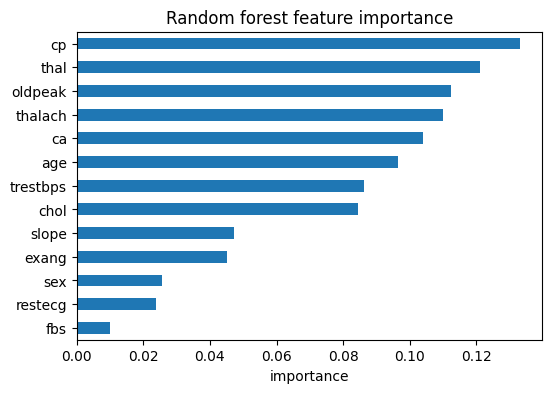

In [15]:
# ⭐ Exercise 2 — แบบฝึกหัดที่ 2: ความสำคัญของตัวแปรใน random forest
# random forest ได้รับการฝึกไว้แล้ว ให้นำค่าความสำคัญของตัวแปรมาสร้างตารางและแผนภูมิ
# สิ่งที่ต้องทำ: แทนที่ `...` ด้วย   rf.feature_importances_
# คำแนะนำ: พิมพ์ "rf." ตามด้วยชื่อ attribute ส่วนที่เหลือของเซลล์จะเรียงลำดับและสร้างแผนภูมิโดยอัตโนมัติ

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   ในทางการแพทย์ ไม่เพียงต้องรู้ว่าโมเดลทำนายแม่นเพียงใด แต่ต้องรู้ด้วยว่า "โมเดลอาศัยข้อมูลใด"
#   เซลล์นี้จึง
#   1) ฝึกโมเดล random forest ด้วยข้อมูลชุดฝึก
#   2) ดึงค่า "ความสำคัญของตัวแปร (feature importance)" ของแต่ละตัวแปรออกมาเป็นตาราง
#      (ค่ามาก = ตัวแปรนั้นช่วยแยกผู้ป่วยที่เป็นโรคออกจากผู้ที่ไม่เป็นโรคได้มาก แต่ไม่บอกทิศทาง)
#   3) วาดแผนภูมิแท่งแนวนอนเรียงจากตัวแปรที่สำคัญน้อยไปมาก
#   สิ่งที่ผู้เรียนจะเห็น: แผนภูมิแท่งแสดงความสำคัญของตัวแปรทั้ง 13 ตัว (ตัวที่สำคัญที่สุดอยู่บนสุด)
#   ผู้เรียนต้องแก้ไขเฉพาะบรรทัดที่มี `...` ตามคำแนะนำด้านบน
# ============================================================================

# สร้างโมเดล random forest แล้วฝึกโมเดลทันทีด้วย .fit(...) จากนั้นเก็บโมเดลที่ฝึกแล้วไว้ในตัวแปร rf
#   - RandomForestClassifier(...) : สร้างโมเดล random forest (นำเข้าไว้แล้วจากเซลล์ก่อนหน้า)
#       - n_estimators=300 : ใช้ต้นไม้ 300 ต้น
#       - random_state=42  : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิม
#   - .fit(X_tr, y_tr) : "ฝึก (train)" โมเดลด้วยตัวแปรต้นชุดฝึก X_tr และคำตอบชุดฝึก y_tr
#       แล้วคืนค่าเป็นตัวโมเดลเอง จึงเขียนต่อท้ายในบรรทัดเดียวได้
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_tr, y_tr)

# สร้างตาราง Series (ตารางคอลัมน์เดียวของ pandas) เก็บค่าความสำคัญของตัวแปร แล้วเก็บไว้ใน importances
#   - importances = pd.Series(importances = pd.Series(rf.feature_importances_, index=X.columns) , index=X.columns) (จุดสามจุด) : ช่องว่างที่ผู้เรียนต้องเติม คือ "ค่าความสำคัญของตัวแปร" ที่เก็บอยู่ในโมเดล rf
#                       (ดูคำแนะนำด้านบน: พิมพ์ rf. ตามด้วยชื่อ attribute)
#   - index=X.columns : ใช้ชื่อคอลัมน์ของ X (ชื่อตัวแปรทั้ง 13 ตัว) เป็นหัวแถว ให้รู้ว่าค่าใดเป็นของตัวแปรใด
#   - # TODO : เครื่องหมายบอกว่าบรรทัดนี้ต้องแก้ไข
importances = pd.Series(rf.feature_importances_, index=X.columns)   # TODO

# วาดแผนภูมิแท่งแนวนอน โดยทำต่อกันเป็นลำดับดังนี้
#   1) importances.sort_values() : เรียงค่าจากน้อยไปมาก (ค่าเริ่มต้น) แท่งที่ยาวที่สุดจึงอยู่ด้านบนของแผนภูมิ
#   2) .plot.barh(...)           : วาดแผนภูมิแท่งแนวนอน (barh = horizontal bar) ด้วยความสามารถวาดกราฟของ pandas
#       - figsize=(6, 4) : ขนาดรูป กว้าง 6 นิ้ว สูง 4 นิ้ว
#       - title="plt.xlabel("importance"); plt.show()"    : ชื่อแผนภูมิ (ใช้ภาษาอังกฤษ เพราะฟอนต์เริ่มต้นใน Colab ไม่รองรับภาษาไทย)
importances.sort_values().plot.barh(figsize=(6, 4), title="Random forest feature importance")
# บรรทัดนี้มี 2 คำสั่งคั่นด้วยเครื่องหมาย ; (เขียนหลายคำสั่งในบรรทัดเดียวได้)
#   - plt.xlabel("importance") : ตั้งชื่อแกนนอน (แกน x) ว่า importance (ความสำคัญ)
#   - plt.show()               : แสดงแผนภูมิออกทางหน้าจอ
plt.xlabel("importance"); plt.show()

In [ ]:
# @title ✅ เฉลย — หากไม่สามารถทำแบบฝึกหัดได้ ให้รันเซลล์นี้ (ดับเบิลคลิกเพื่อแสดงโค้ด) { display-mode: "form" }
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้ (เฉลยแบบฝึกหัดที่ 2)
#   ฝึก random forest แล้วดึงค่าความสำคัญของตัวแปร (feature importance) มาแสดงเป็นแผนภูมิแท่ง
#   เพื่อดูว่าโมเดลอาศัยตัวแปรทางคลินิกใดมากที่สุดในการแยกผู้ป่วยที่เป็นโรคกับไม่เป็นโรค
#   สิ่งที่ผู้เรียนจะเห็น: แผนภูมิแท่งแนวนอน ตัวแปรที่สำคัญที่สุดอยู่บนสุด
# ============================================================================
# สร้างโมเดล random forest (ต้นไม้ 300 ต้น, random_state=42 เพื่อให้ได้ผลซ้ำเดิม)
#   แล้วฝึกด้วย .fit(X_tr, y_tr) คือข้อมูลตัวแปรต้นและคำตอบของชุดฝึก จากนั้นเก็บไว้ใน rf
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_tr, y_tr)

# สร้าง Series (ตารางคอลัมน์เดียว) เก็บความสำคัญของตัวแปร
#   - rf.feature_importances_ : attribute (ค่าที่เก็บอยู่ในโมเดล) ของ random forest ที่ฝึกแล้ว
#       เป็นชุดตัวเลข 1 ค่าต่อ 1 ตัวแปร บอกว่าตัวแปรนั้นช่วยให้ต้นไม้แยกกลุ่มผู้ป่วยได้มากเพียงใด
#       (ทุกค่ารวมกันได้ 1; ขีดล่าง _ ท้ายชื่อเป็นธรรมเนียมของ sklearn หมายถึงค่าที่ได้หลังการฝึก)
#   - index=X.columns : ใช้ชื่อตัวแปรเป็นหัวแถว
importances = pd.Series(rf.feature_importances_, index=X.columns)

# เรียงค่าจากน้อยไปมากด้วย .sort_values() แล้ววาดแผนภูมิแท่งแนวนอนด้วย .plot.barh(...)
#   - figsize=(6, 4) : ขนาดรูป กว้าง 6 สูง 4 นิ้ว
#   - title="..."    : ชื่อแผนภูมิ
importances.sort_values().plot.barh(figsize=(6, 4), title="Random forest feature importance")
# ตั้งชื่อแกนนอนว่า importance ด้วย plt.xlabel(...) แล้วแสดงแผนภูมิด้วย plt.show() (สองคำสั่งคั่นด้วย ;)
plt.xlabel("importance"); plt.show()

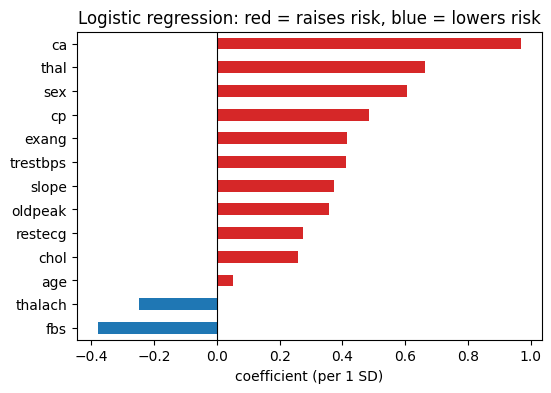

In [16]:
# น้ำหนักของ logistic regression (ตัวแปรผ่านการปรับมาตรฐานแล้ว จึงเปรียบเทียบขนาดกันได้)
# ข้อความในแผนภูมิเป็นภาษาอังกฤษ เนื่องจากฟอนต์เริ่มต้นของ matplotlib บน Colab ไม่รองรับภาษาไทย

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   แสดง "สัมประสิทธิ์ (coefficients)" หรือน้ำหนักของแต่ละตัวแปรในโมเดล logistic regression
#   ต่างจากความสำคัญของตัวแปรใน random forest ตรงที่สัมประสิทธิ์มี "เครื่องหมาย" บอกทิศทางด้วย
#     - ค่าบวก (แท่งสีแดง)    : ค่าตัวแปรสูงขึ้น -> ความเสี่ยงที่ทำนายสูงขึ้น
#     - ค่าลบ  (แท่งสีน้ำเงิน) : ค่าตัวแปรสูงขึ้น -> ความเสี่ยงที่ทำนายต่ำลง
#   เนื่องจากตัวแปรถูกปรับมาตรฐานแล้ว ค่าจึงหมายถึงผลต่อ 1 ส่วนเบี่ยงเบนมาตรฐาน
#   (standard deviation, SD) ทำให้เปรียบเทียบข้ามตัวแปรที่มีหน่วยต่างกันได้
#   สิ่งที่ผู้เรียนจะเห็น: แผนภูมิแท่งแนวนอนสีแดง/น้ำเงิน เรียงจากค่าลบมากที่สุดไปค่าบวกมากที่สุด
#   ข้อควรระวัง: แสดงเพียงความสัมพันธ์ (association) ในข้อมูล มิใช่ความเป็นเหตุเป็นผล (causation)
# ============================================================================

# ดึงโมเดล "LogReg" (pipeline: ปรับมาตรฐาน -> logistic regression) ออกจาก dict models
#   แล้วฝึกด้วย .fit(X_tr, y_tr) (ข้อมูลชุดฝึก) จากนั้นเก็บ pipeline ที่ฝึกแล้วไว้ในตัวแปร logreg
logreg = models["LogReg"].fit(X_tr, y_tr)
# สร้าง Series ของสัมประสิทธิ์ แล้วเรียงจากน้อยไปมาก เก็บไว้ใน coef โดยทำเป็นลำดับดังนี้
#   1) logreg[-1]   : เลือกขั้นตอนสุดท้ายของ pipeline (ดัชนี -1 = ตัวสุดท้าย) คือตัว LogisticRegression
#   2) .coef_       : attribute เก็บสัมประสิทธิ์ที่โมเดลเรียนรู้ได้ อยู่ในรูปตาราง 1 แถว x 13 คอลัมน์
#   3) [0]          : เลือกแถวแรก (ดัชนีใน Python เริ่มนับจาก 0) ได้ตัวเลข 13 ค่า เรียงตามตัวแปร
#   4) pd.Series(..., index=X.columns) : ทำเป็น Series โดยใช้ชื่อตัวแปรเป็นหัวแถว
#   5) .sort_values() : เรียงค่าจากน้อย (ลบมาก) ไปมาก (บวกมาก)
coef = pd.Series(logreg[-1].coef_[0], index=X.columns).sort_values()
# วาดแผนภูมิแท่งแนวนอนของ coef ด้วย .plot.barh(...)
#   - figsize=(6, 4) : ขนาดรูป กว้าง 6 สูง 4 นิ้ว
#   - color=np.where(coef > 0, "tab:red", "tab:blue") : กำหนดสีของแต่ละแท่ง
#       np.where(เงื่อนไข, ค่าเมื่อจริง, ค่าเมื่อเท็จ) เป็นฟังก์ชันของ numpy ที่เลือกค่าทีละตัว
#       ถ้าสัมประสิทธิ์ > 0 ใช้สีแดง ("tab:red") มิฉะนั้นใช้สีน้ำเงิน ("tab:blue")
#   - title="..." : ชื่อแผนภูมิ (สีแดง = เพิ่มความเสี่ยง, สีน้ำเงิน = ลดความเสี่ยง)
coef.plot.barh(figsize=(6, 4), color=np.where(coef > 0, "tab:red", "tab:blue"),
               title="Logistic regression: red = raises risk, blue = lowers risk")
# บรรทัดนี้มี 3 คำสั่งคั่นด้วย ;
#   - plt.axvline(0, color="k", lw=0.8) : ลากเส้นแนวตั้งที่ตำแหน่ง x = 0 เพื่อแบ่งค่าบวก/ลบ
#       - 0           : ตำแหน่งบนแกนนอนที่จะลากเส้น
#       - color="k"   : สีดำ (k = black)
#       - lw=0.8      : ความหนาของเส้น (line width) 0.8
#   - plt.xlabel("coefficient (per 1 SD)") : ตั้งชื่อแกนนอนว่า สัมประสิทธิ์ (ต่อ 1 ส่วนเบี่ยงเบนมาตรฐาน)
#   - plt.show() : แสดงแผนภูมิ
plt.axvline(0, color="k", lw=0.8); plt.xlabel("coefficient (per 1 SD)"); plt.show()

> 💡 **คำอธิบายผลลัพธ์** แผนภูมิทั้งสองจัดอันดับตัวแปร ในแผนภูมิ logistic regression สีแดงหมายถึงเพิ่มความเสี่ยง และสีน้ำเงินหมายถึงลดความเสี่ยง ส่วน "per 1 SD" หมายถึงต่อหนึ่งส่วนเบี่ยงเบนมาตรฐาน (standard deviation) ซึ่งเป็นขนาดความแตกต่างโดยทั่วไประหว่างผู้ป่วย จึงเปรียบเทียบข้ามตัวแปรที่มีหน่วยต่างกันได้ ทั้งนี้ แผนภูมิแสดงเฉพาะสิ่งที่โมเดล*ใช้* ซึ่งเป็น**ความสัมพันธ์ (association) ในชุดข้อมูลนี้ มิใช่ความเป็นเหตุเป็นผล (causation)**

✍️ **คำถาม A2** โปรดระบุ**ตัวแปรที่มีความสำคัญสูงสุด 3 อันดับแรก**ของ random forest แผนภูมิทั้งสองสอดคล้องกันโดยรวมหรือไม่ และจงอธิบายเชิงคลินิกโดยอ้างอิงตารางคอลัมน์ข้างต้นว่า เหตุใดตัวแปรเหล่านี้จึงสามารถทำนายโรคหลอดเลือดหัวใจได้

✍️ **คำตอบ:**
จากกราฟ Random Forest ตัวแปรที่มีความสำคัญสูงสุด 3 อันดับแรกคือ cp, thal และ oldpeak
cp (chest pain type) หรือชนิดของอาการเจ็บหน้าอก เป็นตัวแปรที่สำคัญที่สุดใน Random Forest ซึ่งสมเหตุสมผลในทางคลินิก เพราะลักษณะของอาการเจ็บหน้าอกเป็นข้อมูลสำคัญที่แพทย์ใช้ประเมินผู้ป่วยที่สงสัยโรคหลอดเลือดหัวใจ เช่น อาการเจ็บแน่นหน้าอกที่สัมพันธ์กับการออกแรงอาจทำให้นึกถึงภาวะกล้ามเนื้อหัวใจขาดเลือดมากขึ้น อย่างไรก็ตาม cp เป็นตัวแปรแบบกลุ่ม ดังนั้นความหมายของตัวเลขแต่ละค่าขึ้นอยู่กับว่าชุดข้อมูลกำหนดรหัสไว้แบบใด
thal เป็นตัวแปรที่เกี่ยวข้องกับผลการประเมินภาวะเลือดไปเลี้ยงกล้ามเนื้อหัวใจและถูกใช้เป็นข้อมูลประกอบการวินิจฉัยในชุดข้อมูลนี้ การที่ Random Forest ให้น้ำหนักกับตัวแปรนี้สูงจึงสะท้อนว่า thal สามารถช่วยแยกผู้ป่วยที่มีและไม่มีโรคหัวใจได้ค่อนข้างดี
oldpeak หมายถึงระดับ ST depression ที่เกิดขึ้นเมื่อออกกำลังกายเมื่อเทียบกับช่วงพัก ถ้าเกิด ST depression มากขึ้น อาจสัมพันธ์กับภาวะกล้ามเนื้อหัวใจขาดเลือด จึงเป็นตัวแปรที่มีประโยชน์ในการประเมินโรคหลอดเลือดหัวใจ
เมื่อเทียบกับกราฟ Logistic Regression จะเห็นว่า ทั้ง thal, cp และ oldpeak มีค่าสัมประสิทธิ์เป็นบวก ในโมเดลนี้ จึงถือว่า สอดคล้องกันบางส่วน กล่าวคือ Random Forest มองว่าตัวแปรเหล่านี้สำคัญ และ Logistic Regression ก็พบว่าตัวแปรเหล่านี้สัมพันธ์กับการเพิ่มโอกาสที่โมเดลจะทำนายเป็นกลุ่มโรคหัวใจตามการเข้ารหัสของข้อมูล
แต่ไม่ควรบอกว่า “สองโมเดลเหมือนกันทั้งหมด” เพราะลำดับความสำคัญต่างกัน เช่น ใน Logistic Regression ตัวแปร ca มีค่าสัมประสิทธิ์สูงที่สุด ขณะที่ใน Random Forest ตัวแปร cp มี Feature Importance สูงที่สุด
สิ่งสำคัญคือ Feature Importance ของ Random Forest บอกเพียงว่าตัวแปรมีอิทธิพลต่อการทำนายมากแค่ไหน แต่ไม่ได้บอกทิศทางว่าเพิ่มหรือลดความเสี่ยง ส่วน Logistic Regression สามารถดูทิศทางจากเครื่องหมายของ coefficient ได้

✍️ **คำถาม A3** จากแผนภูมิ logistic regression ให้พิจารณา*ทิศทาง*ของ `thalach` (อัตราการเต้นของหัวใจสูงสุด) และ `oldpeak` (ST depression) ว่าสอดคล้องกับหลักการของการทดสอบสมรรถภาพหัวใจด้วยการออกกำลังกาย (exercise stress test) หรือไม่ นอกจากนี้ `fbs` (ระดับน้ำตาลในเลือดขณะอดอาหารสูง) และ `chol` (คอเลสเตอรอล) เป็นปัจจัยเสี่ยงที่ทราบกันดี โมเดลจัดอันดับตัวแปรทั้งสองไว้อย่างไร และ `fbs` มีทิศทางใด จงเสนอเหตุผลที่เป็นไปได้ (พิจารณาเกณฑ์การส่งตัวผู้ป่วยมาตรวจสวนหัวใจ ขนาดตัวอย่างที่มีจำกัด และการที่ตัวแปรซึ่งมีความสัมพันธ์กัน "แบ่งน้ำหนัก" ร่วมกัน)

✍️ **คำตอบ:**จาก Logistic Regression จะเห็นว่า thalach มี coefficient เป็นค่าลบ ส่วน oldpeak มี coefficient เป็นค่าบวก
thalach คือ อัตราการเต้นหัวใจสูงสุดที่ทำได้ ในการออกกำลังกาย ในโมเดลนี้ เมื่อค่า thalach สูงขึ้น จะสัมพันธ์กับโอกาสที่โมเดลทำนายว่าเป็นโรคหัวใจลดลง กล่าวง่าย ๆ คือ ผู้ที่สามารถเพิ่มอัตราการเต้นหัวใจระหว่างออกกำลังกายได้ดี อาจมีสมรรถภาพของหัวใจดีกว่าผู้ที่ตอบสนองต่อการออกกำลังกายได้น้อย อย่างไรก็ตาม ในการประเมินจริงไม่ควรดูค่า thalach เพียงตัวเดียว ต้องพิจารณาอายุ อาการ ผล ECG และข้อมูลอื่นร่วมด้วย
ส่วน oldpeak คือ ST depression ที่เกิดจากการออกกำลังกาย จากกราฟมี coefficient เป็นบวก หมายความว่าเมื่อ oldpeak เพิ่มขึ้น โมเดลจะทำนายความเสี่ยงโรคหัวใจเพิ่มขึ้น ซึ่งถือว่า สอดคล้องกับหลักการของ exercise stress test เพราะ ST depression หลังออกกำลังกายสามารถเป็นสัญญาณที่สัมพันธ์กับ myocardial ischemia หรือภาวะกล้ามเนื้อหัวใจขาดเลือด
ดังนั้นทิศทางของสองตัวแปรนี้สามารถอธิบายง่าย ๆ ว่า thalach สูง → โมเดลทำนายความเสี่ยงลดลง ส่วน oldpeak สูง → โมเดลทำนายความเสี่ยงเพิ่มขึ้น และโดยภาพรวมถือว่าสอดคล้องกับเหตุผลทางคลินิก

## Part B — การเรียนรู้แบบไม่มีผู้สอน (unsupervised learning): การจำแนกกลุ่มผู้ป่วย

**การเรียนรู้แบบไม่มีผู้สอน** คือการค้นหาโครงสร้างในข้อมูล*โดยไม่ใช้*ป้ายกำกับ ส่วนนี้ตั้งคำถามว่า *ผู้ป่วยสามารถแบ่งออกเป็นกลุ่มตามลักษณะที่เกิดขึ้นเองตามธรรมชาติ (phenotypes) ได้หรือไม่* โดยอัลกอริทึมไม่ได้ใช้คอลัมน์ `target` เลย

- **การวิเคราะห์องค์ประกอบหลัก (principal component analysis, PCA)** ลดตัวแปร 13 ตัวให้เหลือแกนสรุป 2 แกน (PC1, PC2) เพื่อแสดงผู้ป่วยแต่ละรายเป็นจุดบนแผนภูมิ
- **K-means** แบ่งผู้ป่วยออกเป็น *K* กลุ่ม (clusters) ตามความคล้ายคลึงกัน

ก่อนการวิเคราะห์ ต้อง*ปรับมาตรฐาน (standardise)* ตัวแปรให้อยู่ในมาตราเดียวกัน มิฉะนั้นคอเลสเตอรอล (≈ 250) จะมีอิทธิพลเหนือ `ca` (0–3)

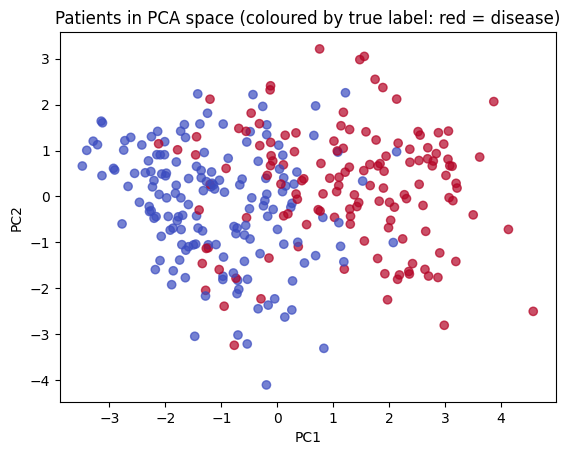

In [17]:
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   เริ่ม Part B การเรียนรู้แบบไม่มีผู้สอน (unsupervised learning) โดย
#   1) ปรับมาตรฐาน (standardise) ตัวแปรทั้ง 13 ตัวให้อยู่ในมาตราเดียวกัน
#      (มิฉะนั้นคอเลสเตอรอล ซึ่งมีค่าประมาณ 250 จะมีอิทธิพลเหนือ ca ซึ่งมีค่า 0-3)
#   2) ใช้การวิเคราะห์องค์ประกอบหลัก (principal component analysis, PCA) ย่อตัวแปร 13 ตัว
#      ให้เหลือแกนสรุป 2 แกน (PC1, PC2) เพื่อวาดผู้ป่วยแต่ละรายเป็นจุดบนแผนภาพ 2 มิติ
#   3) วาดแผนภาพการกระจาย (scatter plot) โดยระบายสีตามการวินิจฉัยจริง
#      (สีมีไว้ให้ผู้เรียนพิจารณาเท่านั้น PCA ไม่ได้ใช้คอลัมน์ target เลย)
#   สิ่งที่ผู้เรียนจะเห็น: จุดผู้ป่วย 297 จุด สีแดง = เป็นโรค สีน้ำเงิน = ไม่เป็นโรค
#   ผลลัพธ์ Xs (ข้อมูลที่ปรับมาตรฐานแล้ว) และ pca (พิกัด 2 มิติ) จะใช้ต่อในเซลล์ K-means
# ============================================================================

# นำเข้า StandardScaler (เครื่องมือปรับมาตรฐานให้ค่าเฉลี่ย 0 และส่วนเบี่ยงเบนมาตรฐาน 1) จาก sklearn.preprocessing
from sklearn.preprocessing import StandardScaler
# นำเข้า PCA (การวิเคราะห์องค์ประกอบหลัก) จาก sklearn.decomposition (เครื่องมือย่อมิติของข้อมูล)
from sklearn.decomposition import PCA
# นำเข้า KMeans (อัลกอริทึมจัดกลุ่ม K-means) จาก sklearn.cluster (จะใช้ในเซลล์ถัดไป)
from sklearn.cluster import KMeans

# ปรับมาตรฐานตัวแปรต้นทั้งหมด แล้วเก็บผลไว้ใน Xs (s = scaled)
#   - StandardScaler()       : สร้างเครื่องมือปรับมาตรฐาน
#   - .fit_transform(X)      : ทำ 2 ขั้นในคำสั่งเดียว
#       fit = คำนวณค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของแต่ละคอลัมน์ใน X
#       transform = แปลงค่าทุกช่องเป็น (ค่า - ค่าเฉลี่ย) / ส่วนเบี่ยงเบนมาตรฐาน
#   - ใช้ X (ไม่มีคอลัมน์ target) เพราะการเรียนรู้แบบไม่มีผู้สอนไม่ใช้คำตอบ
Xs = StandardScaler().fit_transform(X)
# ย่อข้อมูล 13 มิติให้เหลือ 2 มิติด้วย PCA แล้วเก็บพิกัดใหม่ไว้ในตัวแปร pca
#   - PCA(n_components=2) : สร้างเครื่องมือ PCA ที่เก็บไว้ 2 องค์ประกอบหลัก (PC1 และ PC2)
#       ซึ่งเป็นแกนสรุปที่อธิบายความแตกต่างระหว่างผู้ป่วยได้มากที่สุดเป็นอันดับ 1 และ 2
#   - .fit_transform(Xs)  : หาแกนสรุปจาก Xs แล้วแปลงผู้ป่วยแต่ละรายเป็นพิกัด (PC1, PC2)
#   - ผลลัพธ์เป็นอาร์เรย์ของ numpy ขนาด (จำนวนผู้ป่วย, 2)
pca = PCA(n_components=2).fit_transform(Xs)

# วาดแผนภาพการกระจาย (scatter plot) ด้วย plt.scatter(...) ของ matplotlib
#   - pca[:,0] : พิกัดแกนนอน = คอลัมน์ที่ 0 (PC1) ของทุกแถว  (: หมายถึง "ทุกแถว")
#   - pca[:,1] : พิกัดแกนตั้ง = คอลัมน์ที่ 1 (PC2) ของทุกแถว
#   - c=y            : ระบายสีจุดตามค่า y (การวินิจฉัยจริง 0/1)
#   - cmap="coolwarm": ชุดสีจากน้ำเงิน (ค่าต่ำ = 0 ไม่เป็นโรค) ไปแดง (ค่าสูง = 1 เป็นโรค)
#   - alpha=0.7      : ความทึบของจุด 70% (โปร่งแสงเล็กน้อย เพื่อให้เห็นจุดที่ซ้อนกัน)
plt.scatter(pca[:,0], pca[:,1], c=y, cmap="coolwarm", alpha=0.7)
# บรรทัดนี้มี 3 คำสั่งคั่นด้วย ;
#   - plt.xlabel("PC1") : ตั้งชื่อแกนนอนว่า PC1
#   - plt.ylabel("PC2") : ตั้งชื่อแกนตั้งว่า PC2
#   - plt.title("...")  : ตั้งชื่อแผนภาพ (ผู้ป่วยในพื้นที่ PCA ระบายสีตามป้ายกำกับจริง แดง = เป็นโรค)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Patients in PCA space (coloured by true label: red = disease)")
# แสดงแผนภาพออกทางหน้าจอ
plt.show()

> 💡 **คำอธิบายผลลัพธ์** แต่ละจุดแทนผู้ป่วยหนึ่งราย สีแสดงการวินิจฉัยจริง (แดง = เป็นโรค, น้ำเงิน = ไม่เป็นโรค) ซึ่งแสดงไว้*เพื่อการพิจารณาของผู้เรียนเท่านั้น* PCA มิได้ใช้ข้อมูลนี้ หากจุดสีแดงและสีน้ำเงินอยู่ต่างบริเวณกัน แสดงว่าตัวแปรต่าง ๆ มี "รูปแบบของโรค" อยู่แล้วในตัว

In [ ]:
# ⭐ Exercise 3 — แบบฝึกหัดที่ 3: การจัดกลุ่มด้วย K-means
# K-means ต้องกำหนดจำนวนกลุ่ม (clusters) ที่ต้องการ
# สิ่งที่ต้องทำ: แทนที่ `...` ด้วยเลข 2   (บรรทัดจะเป็น  K = 2 )
# ในคำถาม B2 ให้กลับมาทดลอง K = 3 แล้วรันเซลล์นี้และเซลล์โปรไฟล์ด้านล่างอีกครั้ง

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   ใช้อัลกอริทึม K-means แบ่งผู้ป่วยออกเป็น K กลุ่ม (clusters) ตามความคล้ายคลึงของตัวแปรทางคลินิก
#   โดยไม่ใช้คำตอบ (target) เลย เพื่อค้นหากลุ่มผู้ป่วยที่เกิดขึ้นเองตามธรรมชาติ (phenotypes)
#   ขั้นตอน:
#   1) กำหนดจำนวนกลุ่ม K (ผู้เรียนเติมเอง)
#   2) ฝึก K-means บนข้อมูลที่ปรับมาตรฐานแล้ว (Xs) และได้หมายเลขกลุ่มของผู้ป่วยแต่ละราย
#   3) วาดผู้ป่วยบนแผนภาพ PCA เดิม แต่ระบายสีตามกลุ่มที่ K-means หาได้
#   4) สร้างตารางไขว้ (cross-table) เทียบกลุ่มที่ได้กับการวินิจฉัยจริง
#   สิ่งที่ผู้เรียนจะเห็น: แผนภาพจุดที่ระบายสีตามกลุ่ม และตารางนับจำนวนผู้ป่วย (กลุ่ม x การวินิจฉัย)
#   หมายเหตุ: หมายเลขกลุ่ม (0, 1, ...) เป็นเพียงชื่อเรียก ไม่ได้บอกความรุนแรง
# ============================================================================

# สร้างตัวแปร K เก็บจำนวนกลุ่มที่ต้องการ
#   - ... (จุดสามจุด) : ช่องว่างที่ผู้เรียนต้องแทนที่ด้วยตัวเลขตามคำแนะนำด้านบน
#   - # TODO : เครื่องหมายบอกว่าบรรทัดนี้ต้องแก้ไข
K = ...   # TODO: จำนวนกลุ่ม

# สร้างโมเดล K-means แล้วฝึกด้วย .fit(Xs) จากนั้นเก็บโมเดลที่ฝึกแล้วไว้ในตัวแปร km
#   - KMeans(...) : อัลกอริทึมจัดกลุ่ม K-means จาก sklearn.cluster (นำเข้าไว้ในเซลล์ก่อนหน้า)
#       - n_clusters=K    : จำนวนกลุ่มที่ต้องการ ใช้ค่าจากตัวแปร K
#       - n_init=10       : ลองเริ่มจัดกลุ่มจากจุดตั้งต้นแบบสุ่ม 10 ครั้ง แล้วเลือกผลที่ดีที่สุด
#                           (ลดโอกาสได้ผลที่ไม่ดีจากการสุ่มจุดเริ่มต้นเพียงครั้งเดียว)
#       - random_state=42 : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิม
#   - .fit(Xs) : ฝึกด้วยข้อมูลที่ปรับมาตรฐานแล้ว (ไม่มีคอลัมน์ target)
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
# ดึงหมายเลขกลุ่มของผู้ป่วยแต่ละรายจาก attribute .labels_ ของโมเดลที่ฝึกแล้ว เก็บไว้ในตัวแปร clusters
clusters = km.labels_          # หมายเลขกลุ่ม (0, 1, ...) ของผู้ป่วยแต่ละราย

# วาดแผนภาพการกระจายบนพิกัด PCA เดิม (จากเซลล์ก่อนหน้า) แต่คราวนี้ระบายสีตามกลุ่ม
#   - pca[:,0], pca[:,1] : พิกัด PC1 (แกนนอน) และ PC2 (แกนตั้ง) ของผู้ป่วยทุกราย
#   - c=clusters         : ระบายสีตามหมายเลขกลุ่มที่ K-means หาได้
#   - cmap="viridis"     : ชุดสีไล่จากม่วง-เขียว-เหลือง
#   - alpha=0.7          : ความทึบของจุด 70%
plt.scatter(pca[:,0], pca[:,1], c=clusters, cmap="viridis", alpha=0.7)
# บรรทัดนี้มี 4 คำสั่งคั่นด้วย ;
#   - plt.xlabel("PC1"), plt.ylabel("PC2") : ตั้งชื่อแกนนอนและแกนตั้ง
#   - plt.title(f"K-means clusters (K={K})") : ตั้งชื่อแผนภาพ โดยใช้ f-string แทรกค่า K ลงใน { }
#   - plt.show() : แสดงแผนภาพ
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"K-means clusters (K={K})"); plt.show()

# พิมพ์ข้อความอธิบายวิธีอ่านตารางไขว้ด้านล่าง
print("แถว = กลุ่ม (cluster), คอลัมน์ = การวินิจฉัยจริง (0 = ไม่เป็นโรค, 1 = เป็นโรค)")
# สร้างและพิมพ์ตารางไขว้ด้วย pd.crosstab(...) ของ pandas (นับจำนวนผู้ป่วยในแต่ละคู่ค่า)
#   - clusters : ใช้เป็นแถวของตาราง (หมายเลขกลุ่ม)
#   - y        : ใช้เป็นคอลัมน์ของตาราง (การวินิจฉัยจริง 0/1)
print(pd.crosstab(clusters, y))

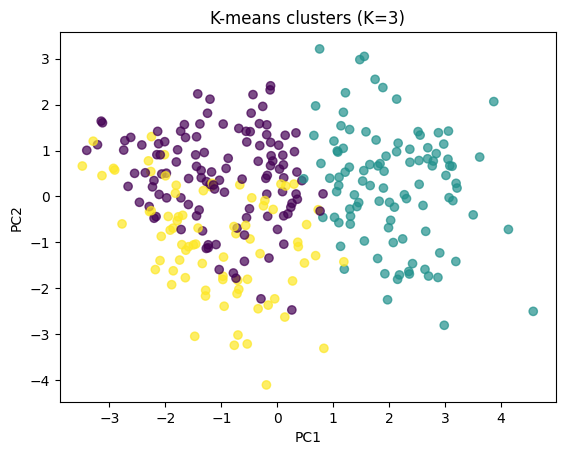

แถว = กลุ่ม (cluster), คอลัมน์ = การวินิจฉัยจริง (0 = ไม่เป็นโรค, 1 = เป็นโรค)
target   0   1
row_0         
0       79  38
1       10  91
2       71   8


In [18]:
# ⭐ Exercise 3 — แบบฝึกหัดที่ 3: การจัดกลุ่มด้วย K-means
# K-means ต้องกำหนดจำนวนกลุ่ม (clusters) ที่ต้องการ
# สิ่งที่ต้องทำ: แทนที่ `...` ด้วยเลข 2   (บรรทัดจะเป็น  K = 2 )
# ในคำถาม B2 ให้กลับมาทดลอง K = 3 แล้วรันเซลล์นี้และเซลล์โปรไฟล์ด้านล่างอีกครั้ง

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   ใช้อัลกอริทึม K-means แบ่งผู้ป่วยออกเป็น K กลุ่ม (clusters) ตามความคล้ายคลึงของตัวแปรทางคลินิก
#   โดยไม่ใช้คำตอบ (target) เลย เพื่อค้นหากลุ่มผู้ป่วยที่เกิดขึ้นเองตามธรรมชาติ (phenotypes)
#   ขั้นตอน:
#   1) กำหนดจำนวนกลุ่ม K (ผู้เรียนเติมเอง)
#   2) ฝึก K-means บนข้อมูลที่ปรับมาตรฐานแล้ว (Xs) และได้หมายเลขกลุ่มของผู้ป่วยแต่ละราย
#   3) วาดผู้ป่วยบนแผนภาพ PCA เดิม แต่ระบายสีตามกลุ่มที่ K-means หาได้
#   4) สร้างตารางไขว้ (cross-table) เทียบกลุ่มที่ได้กับการวินิจฉัยจริง
#   สิ่งที่ผู้เรียนจะเห็น: แผนภาพจุดที่ระบายสีตามกลุ่ม และตารางนับจำนวนผู้ป่วย (กลุ่ม x การวินิจฉัย)
#   หมายเหตุ: หมายเลขกลุ่ม (0, 1, ...) เป็นเพียงชื่อเรียก ไม่ได้บอกความรุนแรง
# ============================================================================

# สร้างตัวแปร K เก็บจำนวนกลุ่มที่ต้องการ
#   - 2 (จุดสามจุด) : ช่องว่างที่ผู้เรียนต้องแทนที่ด้วยตัวเลขตามคำแนะนำด้านบน
#   - # TODO : เครื่องหมายบอกว่าบรรทัดนี้ต้องแก้ไข
K = 3   # TODO: จำนวนกลุ่ม

# สร้างโมเดล K-means แล้วฝึกด้วย .fit(Xs) จากนั้นเก็บโมเดลที่ฝึกแล้วไว้ในตัวแปร km
#   - KMeans(km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)) : อัลกอริทึมจัดกลุ่ม K-means จาก sklearn.cluster (นำเข้าไว้ในเซลล์ก่อนหน้า)
#       - n_clusters=K    : จำนวนกลุ่มที่ต้องการ ใช้ค่าจากตัวแปร K
#       - n_init=10       : ลองเริ่มจัดกลุ่มจากจุดตั้งต้นแบบสุ่ม 10 ครั้ง แล้วเลือกผลที่ดีที่สุด
#                           (ลดโอกาสได้ผลที่ไม่ดีจากการสุ่มจุดเริ่มต้นเพียงครั้งเดียว)
#       - random_state=42 : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิม
#   - .fit(Xs) : ฝึกด้วยข้อมูลที่ปรับมาตรฐานแล้ว (ไม่มีคอลัมน์ target)
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
# ดึงหมายเลขกลุ่มของผู้ป่วยแต่ละรายจาก attribute .labels_ ของโมเดลที่ฝึกแล้ว เก็บไว้ในตัวแปร clusters
clusters = km.labels_          # หมายเลขกลุ่ม (0, 1, ...) ของผู้ป่วยแต่ละราย

# วาดแผนภาพการกระจายบนพิกัด PCA เดิม (จากเซลล์ก่อนหน้า) แต่คราวนี้ระบายสีตามกลุ่ม
#   - pca[:,0], pca[:,1] : พิกัด PC1 (แกนนอน) และ PC2 (แกนตั้ง) ของผู้ป่วยทุกราย
#   - c=clusters         : ระบายสีตามหมายเลขกลุ่มที่ K-means หาได้
#   - cmap="viridis"     : ชุดสีไล่จากม่วง-เขียว-เหลือง
#   - alpha=0.7          : ความทึบของจุด 70%
plt.scatter(pca[:,0], pca[:,1], c=clusters, cmap="viridis", alpha=0.7)
# บรรทัดนี้มี 4 คำสั่งคั่นด้วย ;
#   - plt.xlabel("PC1"), plt.ylabel("PC2") : ตั้งชื่อแกนนอนและแกนตั้ง
#   - plt.title(f"K-means clusters (K={K})") : ตั้งชื่อแผนภาพ โดยใช้ f-string แทรกค่า K ลงใน { }
#   - plt.show() : แสดงแผนภาพ
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"K-means clusters (K={K})"); plt.show()

# พิมพ์ข้อความอธิบายวิธีอ่านตารางไขว้ด้านล่าง
print("แถว = กลุ่ม (cluster), คอลัมน์ = การวินิจฉัยจริง (0 = ไม่เป็นโรค, 1 = เป็นโรค)")
# สร้างและพิมพ์ตารางไขว้ด้วย pd.crosstab(...) ของ pandas (นับจำนวนผู้ป่วยในแต่ละคู่ค่า)
#   - clusters : ใช้เป็นแถวของตาราง (หมายเลขกลุ่ม)
#   - y        : ใช้เป็นคอลัมน์ของตาราง (การวินิจฉัยจริง 0/1)
print(pd.crosstab(clusters, y))

In [ ]:
# @title ✅ เฉลย — หากไม่สามารถทำแบบฝึกหัดได้ ให้รันเซลล์นี้ (ดับเบิลคลิกเพื่อแสดงโค้ด) { display-mode: "form" }
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้ (เฉลยแบบฝึกหัดที่ 3)
#   จัดกลุ่มผู้ป่วยด้วย K-means เป็น 2 กลุ่ม (K = 2) โดยไม่ใช้คำตอบ (target)
#   แล้วแสดงกลุ่มบนแผนภาพ PCA และเทียบกลุ่มกับการวินิจฉัยจริงด้วยตารางไขว้ (cross-table)
#   สิ่งที่ผู้เรียนจะเห็น: แผนภาพจุด 2 สี และตารางจำนวนผู้ป่วย (กลุ่ม x การวินิจฉัย)
# ============================================================================
# กำหนดจำนวนกลุ่ม K = 2 (แบ่งผู้ป่วยเป็น 2 กลุ่ม)
K = 2

# สร้างและฝึก K-means บนข้อมูลที่ปรับมาตรฐานแล้ว Xs แล้วเก็บไว้ใน km
#   - n_clusters=K    : จำนวนกลุ่ม = 2
#   - n_init=10       : ลองสุ่มจุดเริ่มต้น 10 ครั้ง แล้วเลือกผลที่ดีที่สุด
#   - random_state=42 : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิม
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
# ดึงหมายเลขกลุ่ม (0 หรือ 1) ของผู้ป่วยแต่ละรายจาก km.labels_ เก็บไว้ใน clusters
clusters = km.labels_

# วาดผู้ป่วยบนพิกัด PCA (PC1, PC2) ระบายสีตามกลุ่ม (c=clusters) ด้วยชุดสี viridis ความทึบ 70% (alpha=0.7)
plt.scatter(pca[:,0], pca[:,1], c=clusters, cmap="viridis", alpha=0.7)
# ตั้งชื่อแกนนอน PC1 แกนตั้ง PC2 ตั้งชื่อแผนภาพ (f-string แทรกค่า K) แล้วแสดงแผนภาพ (4 คำสั่งคั่นด้วย ;)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"K-means clusters (K={K})"); plt.show()

# พิมพ์ข้อความอธิบายวิธีอ่านตารางไขว้
print("แถว = กลุ่ม (cluster), คอลัมน์ = การวินิจฉัยจริง (0 = ไม่เป็นโรค, 1 = เป็นโรค)")
# สร้างและพิมพ์ตารางไขว้ด้วย pd.crosstab(...) แถว = หมายเลขกลุ่ม (clusters), คอลัมน์ = การวินิจฉัยจริง (y)
print(pd.crosstab(clusters, y))

> 💡 **คำอธิบายผลลัพธ์** K-means จัดกลุ่มผู้ป่วยโดยใช้เฉพาะตัวแปรต่าง ๆ จากนั้นตารางไขว้ (cross-table) เปรียบเทียบกลุ่มที่ได้กับการวินิจฉัยจริง หมายเลขกลุ่ม (0, 1, …) เป็นเพียงชื่อเรียกที่กำหนดขึ้นโดยพลการ "กลุ่ม 1" มิได้ "รุนแรงกว่า" "กลุ่ม 0" โดยนิยาม

ขั้นต่อไปคือการบรรยายลักษณะของแต่ละกลุ่มในเชิงคลินิก โดยพิจารณาโปรไฟล์เฉลี่ยของผู้ป่วยในกลุ่ม

In [19]:
# โปรไฟล์เฉลี่ยของผู้ป่วยในแต่ละกลุ่ม

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   บรรยายลักษณะทางคลินิกของแต่ละกลุ่มที่ K-means หาได้ โดยสร้าง "ตารางโปรไฟล์"
#   ที่สรุปค่าเฉลี่ยหรือสัดส่วนของตัวแปรสำคัญในแต่ละกลุ่ม เช่น อายุ สัดส่วนเพศชาย
#   อัตราการเต้นของหัวใจสูงสุด ST depression และอัตราการเป็นโรค (disease_rate)
#   ข้อมูลนำเข้า: ตาราง df และหมายเลขกลุ่ม clusters จากเซลล์ K-means
#   สิ่งที่ผู้เรียนจะเห็น: ตาราง 1 แถวต่อ 1 กลุ่ม ใช้ตั้งชื่อเชิงคลินิกให้แต่ละกลุ่ม (คำถาม B1)
#   หมายเหตุ: disease_rate ใช้คำตอบจริง "ภายหลัง" การจัดกลุ่ม เพื่อตรวจสอบความหมายของกลุ่มเท่านั้น
# ============================================================================

# สร้างตารางโปรไฟล์แล้วเก็บไว้ในตัวแปร profile โดยทำต่อกันเป็นลำดับ
#   1) df.assign(cluster=clusters) : สร้างตารางสำเนาของ df ที่เพิ่มคอลัมน์ใหม่ชื่อ cluster
#        (ค่าในคอลัมน์ = หมายเลขกลุ่มของผู้ป่วยแต่ละราย; df เดิมไม่ถูกแก้ไข)
#   2) .groupby("cluster")         : จัดผู้ป่วยเป็นกลุ่มย่อยตามค่าในคอลัมน์ cluster
#   3) .agg(...)                   : สรุปค่าของแต่ละกลุ่ม (aggregate) ตามที่ระบุในวงเล็บ
#        รูปแบบแต่ละบรรทัดคือ  ชื่อคอลัมน์ใหม่=("คอลัมน์ต้นทาง", วิธีสรุป)
#        - "mean" = ค่าเฉลี่ย, "size" = นับจำนวนแถว
#        - สำหรับคอลัมน์ที่มีค่า 0/1 ค่าเฉลี่ยคือ "สัดส่วน" ของผู้ที่มีค่าเป็น 1
profile = df.assign(cluster=clusters).groupby("cluster").agg(
    # n_patients : จำนวนผู้ป่วยในกลุ่ม ("size" นับจำนวนแถว ใช้คอลัมน์ age เป็นตัวตั้งเท่านั้น)
    n_patients=("age", "size"),
    # age : อายุเฉลี่ยของผู้ป่วยในกลุ่ม
    age=("age", "mean"),
    # male_pct : สัดส่วนเพศชาย (sex: 1 = ชาย, 0 = หญิง ค่าเฉลี่ยจึงเป็นสัดส่วนผู้ชาย)
    male_pct=("sex", "mean"),
    # max_heart_rate : ค่าเฉลี่ยอัตราการเต้นของหัวใจสูงสุดขณะออกกำลังกาย (thalach)
    max_heart_rate=("thalach", "mean"),
    # st_depression : ค่าเฉลี่ยของ ST depression ขณะออกกำลังกาย (oldpeak)
    st_depression=("oldpeak", "mean"),
    # exercise_angina_pct : สัดส่วนผู้ที่เจ็บหน้าอกขณะออกกำลังกาย (exang: 1 = ใช่)
    exercise_angina_pct=("exang", "mean"),
    # vessels_ca : ค่าเฉลี่ยจำนวนหลอดเลือดหลักที่เห็นจากการฉีดสี (ca, 0-3)
    vessels_ca=("ca", "mean"),
    # asymptomatic_cp_pct : สัดส่วนผู้ที่ไม่มีอาการเจ็บหน้าอก (cp = 4, asymptomatic)
    #   - lambda s: ... คือการสร้าง "ฟังก์ชันสั้น ๆ ไม่มีชื่อ" ในบรรทัดเดียว
    #       s = ค่าคอลัมน์ cp ของผู้ป่วยในกลุ่มนั้น
    #   - (s == 4) : ตรวจทีละรายว่า cp เท่ากับ 4 หรือไม่ ได้ True/False
    #   - .mean()  : ค่าเฉลี่ยของ True/False (True = 1, False = 0) จึงได้สัดส่วนผู้ที่ cp = 4
    asymptomatic_cp_pct=("cp", lambda s: (s == 4).mean()),
    # reversible_thal_pct : สัดส่วนผู้ที่ผลตรวจ thallium เป็น reversible defect (thal = 7)
    #   ใช้ lambda แบบเดียวกับบรรทัดก่อนหน้า แต่ตรวจว่า thal เท่ากับ 7
    reversible_thal_pct=("thal", lambda s: (s == 7).mean()),
    # disease_rate : อัตราการเป็นโรค = ค่าเฉลี่ยของ target (1 = เป็นโรค) ในกลุ่ม
    disease_rate=("target", "mean"),
)
# ปัดค่าในตารางให้เหลือทศนิยม 2 ตำแหน่งด้วย .round(2)
#   เป็นบรรทัดสุดท้ายของเซลล์ ตารางจึงแสดงผลโดยอัตโนมัติ (สัดส่วน 0.80 = ร้อยละ 80)
profile.round(2)

,n_patients,age,male_pct,max_heart_rate,st_depression,exercise_angina_pct,vessels_ca,asymptomatic_cp_pct,reversible_thal_pct,disease_rate
cluster,,,,,,,,,,
0,117,50.97,1.00,162.94,0.60,0.12,0.38,0.28,0.37,0.32
1,101,58.20,0.83,130.04,1.98,0.70,1.28,0.84,0.69,0.90
2,79,55.16,0.00,154.85,0.55,0.15,0.34,0.30,0.03,0.10


> 💡 **คำอธิบายผลลัพธ์** แต่ละแถวแทนหนึ่งกลุ่ม ความหมายของคอลัมน์มีดังนี้ `n_patients` = จำนวนผู้ป่วย, `male_pct` = สัดส่วนเพศชาย, `max_heart_rate` = ค่าเฉลี่ยของ `thalach`, `st_depression` = ค่าเฉลี่ยของ `oldpeak`, `exercise_angina_pct` = สัดส่วนผู้ที่มีอาการเจ็บหน้าอกขณะออกกำลังกาย, `vessels_ca` = ค่าเฉลี่ยของ `ca`, `asymptomatic_cp_pct` = สัดส่วนผู้ที่มี `cp` = 4, `reversible_thal_pct` = สัดส่วนผู้ที่มี `thal` = 7 คอลัมน์ `_pct` และ `disease_rate` (อัตราการเป็นโรค) แสดงเป็นสัดส่วน (0.80 = ร้อยละ 80) โดย `disease_rate` ใช้ป้ายกำกับ*ภายหลัง*การจัดกลุ่มเท่านั้น เพื่อตรวจสอบความหมายของกลุ่ม

✍️ **คำถาม B1** โปรดตั้งชื่อเชิงคลินิกโดยสังเขปให้แต่ละกลุ่มโดยอ้างอิงตารางโปรไฟล์ (เช่น "อายุน้อยกว่า สมรรถภาพการออกกำลังกายดี ความเสี่ยงต่ำ" และ "…") และจากตารางไขว้ กลุ่มที่ได้สอดคล้องกับการวินิจฉัยจริงมากน้อยเพียงใด

✍️ **คำตอบ:**- Cluster 0: “อายุน้อย สมรรถภาพหัวใจค่อนข้างดี” อายุเฉลี่ยประมาณ 51 ปี เป็นผู้ชายทั้งหมด มีอัตราการเต้นหัวใจสูงสุดค่อนข้างสูง และมี ST depression ต่ำ อัตราเกิดโรคประมาณ 32%
- Cluster 1: “กลุ่มความเสี่ยงสูง” อายุเฉลี่ยมากที่สุด มี max heart rate ต่ำ, ST depression สูง, exercise angina สูง และจำนวนหลอดเลือดผิดปกติมากกว่า จึงมีอัตราเกิดโรคสูงที่สุดประมาณ 90%
- Cluster 2: “กลุ่มความเสี่ยงต่ำ” เป็นผู้หญิงทั้งหมด มี ST depression และ exercise angina ต่ำ และมีอัตราเกิดโรคต่ำที่สุดประมาณ 10%
ดังนั้น Cluster 1 มีความเสี่ยงสูงที่สุด และ Cluster 2 ต่ำที่สุด

✍️ **คำถาม B2** ให้กำหนด `K = 3` ในแบบฝึกหัดที่ 3 แล้วรันเซลล์ดังกล่าวและเซลล์โปรไฟล์อีกครั้ง กลุ่มที่เพิ่มขึ้นมีลักษณะอย่างไร (คำแนะนำ: พิจารณา `male_pct`) จงอธิบายว่าแพทย์สามารถใช้ประโยชน์จากกลุ่มที่ได้จากการเรียนรู้แบบไม่มีผู้สอนได้อย่างไร และมีข้อควรระวังใดบ้าง (เช่น กลุ่มถูกค้นพบโดยไม่ได้ใช้ผลลัพธ์ทางคลินิก และค่า K ถูกกำหนดโดยผู้วิเคราะห์) เมื่อเสร็จแล้วให้กำหนด `K = 2` ดังเดิม (หรือรันเซลล์เฉลย) ก่อนดำเนินการต่อ

✍️ **คำตอบ:** เมื่อเพิ่มเป็น K = 3 จะเห็นกลุ่มใหม่ที่เด่นชัดคือ Cluster 2 ซึ่งเป็นผู้หญิงทั้งหมด (male_pct = 0) และมีลักษณะความเสี่ยงค่อนข้างต่ำ การแบ่งกลุ่มแบบนี้มีประโยชน์เพราะช่วยให้เราเห็นรูปแบบของผู้ป่วยที่คล้ายกันโดยไม่ต้องใช้ผลโรคมาสอนโมเดลก่อน เช่น อาจใช้แบ่งกลุ่มเพื่อวางแผนการติดตามหรือศึกษาปัจจัยเสี่ยงเพิ่มเติม
อย่างไรก็ตาม ไม่ควรใช้ cluster เพื่อวินิจฉัยโรคโดยตรง เพราะผลการแบ่งกลุ่มขึ้นกับตัวแปรที่เลือก จำนวน cluster และการเตรียมข้อมูล และในกรณีนี้เพศมีผลต่อการแบ่งกลุ่มค่อนข้างมาก จึงควรตรวจสอบกับข้อมูลอื่นเพิ่มเติมก่อนนำไปใช้จริง

## Part C — การเรียนรู้แบบเสริมกำลัง (reinforcement learning, RL) (ตัวอย่างเชิงแนวคิด)

**การเรียนรู้แบบเสริมกำลัง** มุ่งเรียนรู้*นโยบาย (policy)* ว่าควรเลือก**การกระทำ (action)** ใดใน**สถานะ (state)** ต่าง ๆ เพื่อให้ได้**รางวัล (reward)** ระยะยาวสูงสุด โดยอาศัยการลองผิดลองถูก ในทางการแพทย์ เทียบได้กับการตัดสินใจรักษาที่ต่อเนื่องเป็นลำดับ (เช่น การปรับขนาดอินซูลิน การดูแลผู้ป่วยภาวะ sepsis)

ส่วนนี้ใช้สภาพแวดล้อม "การรักษา" จำลองขนาดเล็ก (ไม่ต้องใช้ไลบรารีภายนอก) ดังนี้
- **สถานะ** = ระดับความรุนแรงของผู้ป่วย 0–4 (0 = หายเป็นปกติ, 4 = วิกฤต)
- **การกระทำ** = ไม่รักษา (ผู้ป่วยอาจมีอาการแย่ลง) หรือรักษา (ผู้ป่วยมักมีอาการดีขึ้น)
- **รางวัล** = +10 เมื่อผู้ป่วยหายเป็นปกติ และมี**ต้นทุน (cost)** ทุกครั้งที่ให้การรักษา (ผลข้างเคียง ค่าใช้จ่าย)

เอเจนต์ (agent) ใช้วิธี **Q-learning** โดยเก็บตาราง `Q[ความรุนแรง, การกระทำ]` = "รางวัลในอนาคตที่คาดว่าจะได้รับ หากเลือกการกระทำนี้ในสถานะนี้" และปรับปรุงค่าหลังการจำลองทุกขั้น เมื่อจำลองผู้ป่วยครบ 3,000 ราย เอเจนต์จะเรียนรู้ว่าการกระทำใดให้ผลตอบแทนคุ้มค่า

In [20]:
# สภาพแวดล้อมจำลองและเอเจนต์ Q-learning (สาระสำคัญอยู่ที่แนวคิด มิใช่รายละเอียดของโค้ด)

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   เริ่ม Part C การเรียนรู้แบบเสริมกำลัง (reinforcement learning, RL) โดยสร้าง
#   1) "สภาพแวดล้อม (environment)" จำลองการรักษาอย่างง่าย:
#        สถานะ (state)  = ความรุนแรงของผู้ป่วย 0-4 (0 = หายเป็นปกติ, 4 = วิกฤต)
#        การกระทำ (action) = 0 ไม่รักษา หรือ 1 รักษา
#        รางวัล (reward) = +10 เมื่อผู้ป่วยหาย และมีต้นทุน (cost) ทุกครั้งที่รักษา
#   2) ฟังก์ชัน train_agent(...) : ให้ "เอเจนต์ (agent)" ลองผิดลองถูกกับผู้ป่วยจำลองหลายพันราย
#      แล้วเรียนรู้ตาราง Q ด้วยวิธี Q-learning
#      (Q[ความรุนแรง, การกระทำ] = รางวัลในอนาคตที่คาดว่าจะได้รับ หากเลือกการกระทำนั้นในสถานะนั้น)
#   3) ฟังก์ชัน show_policy(...) : แสดงตาราง Q และ "นโยบาย (policy)" คือการกระทำที่ดีที่สุดในแต่ละระดับความรุนแรง
#   4) ฝึกเอเจนต์เมื่อต้นทุนการรักษา = -1 แล้วแสดงผล
#   สิ่งที่ผู้เรียนจะเห็น: ตาราง Q ขนาด 5 x 2 และรายการการกระทำที่ดีที่สุดสำหรับความรุนแรง 1-4
#   ผู้เรียนไม่จำเป็นต้องเข้าใจโค้ดทุกบรรทัด สาระสำคัญอยู่ที่แนวคิด
# ============================================================================

# สร้างลิสต์ ACTION_NAMES เก็บชื่อการกระทำเป็นภาษาไทย
#   ลำดับในลิสต์ตรงกับหมายเลขการกระทำ: ตำแหน่ง 0 = "ไม่รักษา", ตำแหน่ง 1 = "รักษา"
ACTION_NAMES = ["ไม่รักษา", "รักษา"]

# ----------------------------------------------------------------------------
# ส่วนที่ 1: ฟังก์ชัน train_agent สำหรับฝึกเอเจนต์ด้วย Q-learning และคืนค่าตาราง Q
#   พารามิเตอร์ (มีค่าเริ่มต้นหลังเครื่องหมาย = หากผู้ใช้ไม่ระบุ จะใช้ค่านี้)
#   - treat_cost=-1       : รางวัล (ติดลบ = ต้นทุน) ที่ได้ทุกครั้งที่เลือก "รักษา" เช่น ผลข้างเคียง ค่าใช้จ่าย
#   - sickness_penalty=0  : บทลงโทษต่อขั้นที่ผู้ป่วยยังมีอาการ (คูณกับระดับความรุนแรง) ค่าเริ่มต้น 0 = ไม่ลงโทษ
#   - episodes=3000       : จำนวนรอบการฝึก (episode) คือจำนวนผู้ป่วยจำลองที่เอเจนต์ได้ฝึกด้วย
#   - seed=0              : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิม
# ----------------------------------------------------------------------------
def train_agent(treat_cost=-1, sickness_penalty=0, episodes=3000, seed=0):
    # สร้างตัวสุ่มตัวเลข (random number generator) ของ numpy ด้วย np.random.default_rng(...)
    #   - seed : เลขตั้งต้น ทำให้ลำดับตัวเลขสุ่มเหมือนเดิมทุกครั้งที่รัน
    rng = np.random.default_rng(seed)
    # สร้างตาราง Q เริ่มต้นเป็นศูนย์ทั้งหมดด้วย np.zeros(...)
    #   - (5, 2) : ขนาด 5 แถว (ความรุนแรง 0-4) x 2 คอลัมน์ (การกระทำ: ไม่รักษา, รักษา)
    Q = np.zeros((5, 2))                      # แถว = ความรุนแรง 0..4, คอลัมน์ = [ไม่รักษา, รักษา]

    # ------------------------------------------------------------------------
    # ฟังก์ชันย่อย step (สร้างไว้ภายใน train_agent) จำลอง "1 ขั้นของการรักษา"
    #   - s : สถานะปัจจุบัน (ความรุนแรง 0-4)
    #   - a : การกระทำที่เลือก (0 = ไม่รักษา, 1 = รักษา)
    #   คืนค่า 2 อย่าง: s2 = สถานะถัดไป และ r = รางวัลที่ได้รับในขั้นนี้
    # ------------------------------------------------------------------------
    def step(s, a):
        # if ... else : ตรวจเงื่อนไข ถ้าจริงทำคำสั่งที่ย่อหน้าใต้ if มิฉะนั้นทำคำสั่งใต้ else
        #   - a == 1 : ตรวจว่าการกระทำคือ "รักษา" หรือไม่ (== คือการเปรียบเทียบว่าเท่ากัน)
        if a == 1:                            # รักษา: ความรุนแรงมักลดลง 1-2 ระดับ
            # คำนวณความรุนแรงถัดไปหลังรักษา
            #   - rng.choice([1, 1, 2]) : สุ่มเลือก 1 ค่าจากลิสต์ จึงลดลง 1 ระดับ (โอกาส 2 ใน 3) หรือ 2 ระดับ (1 ใน 3)
            #   - max(0, ...)           : ฟังก์ชันพื้นฐานของ Python เลือกค่าที่มากกว่า เพื่อไม่ให้ความรุนแรงต่ำกว่า 0
            s2 = max(0, s - rng.choice([1, 1, 2]))
            # รางวัลของขั้นนี้ = ต้นทุนการรักษา (ค่าติดลบ)
            r = treat_cost                    # ต้นทุนของการรักษา
        # else : กรณีไม่ได้รักษา (a == 0)
        else:                                 # ไม่รักษา: อาการอาจแย่ลง
            # คำนวณความรุนแรงถัดไปเมื่อไม่รักษา
            #   - rng.choice([0, 0, 1]) : คงเดิม (โอกาส 2 ใน 3) หรือแย่ลง 1 ระดับ (1 ใน 3)
            #   - min(4, ...)           : เลือกค่าที่น้อยกว่า เพื่อไม่ให้ความรุนแรงเกิน 4 (วิกฤต)
            s2 = min(4, s + rng.choice([0, 0, 1]))
            # ไม่รักษาจึงไม่มีต้นทุน รางวัล = 0
            r = 0
        # หักบทลงโทษตามความรุนแรงที่เหลืออยู่ (-= หมายถึง r = r - ...)
        #   ถ้า sickness_penalty = 0 (ค่าเริ่มต้น) บรรทัดนี้จะไม่มีผล
        r -= sickness_penalty * s2            # ไม่บังคับ: บทลงโทษทุกขั้นที่ผู้ป่วยยังมีอาการ
        # ตรวจว่าผู้ป่วยหายเป็นปกติ (ความรุนแรง 0) หรือไม่
        if s2 == 0:
            # ถ้าหาย ให้รางวัลเพิ่ม 10 (+= หมายถึง r = r + 10)
            r += 10                           # รางวัลเมื่อผู้ป่วยหายเป็นปกติ
        # ส่งค่าสถานะถัดไปและรางวัลกลับไปพร้อมกัน 2 ค่า
        return s2, r

    # กำหนดค่าตั้งต้นของการเรียนรู้ 3 ตัวพร้อมกันในบรรทัดเดียว (ค่าทางขวาเรียงตามตัวแปรทางซ้าย)
    #   - alpha = 0.1 : อัตราการเรียนรู้ (learning rate) ปรับค่า Q ทีละ 10% ของความคลาดเคลื่อน
    #   - gamma = 0.9 : ตัวลดค่ารางวัลในอนาคต (discount factor) รางวัลในขั้นถัดไปมีค่า 90% ของรางวัลทันที
    #   - eps   = 0.2 : อัตราการสำรวจ (exploration) มีโอกาส 20% ที่เอเจนต์จะลองสุ่มเลือกการกระทำ
    alpha, gamma, eps = 0.1, 0.9, 0.2         # อัตราการเรียนรู้, ตัวลดค่ารางวัลในอนาคต, อัตราการสำรวจ (exploration)
    # ------------------------------------------------------------------------
    # ลูปการฝึก: วนรอบตามจำนวน episodes (1 รอบ = ผู้ป่วยจำลอง 1 ราย)
    #   - for ... in range(episodes) : วนซ้ำ episodes ครั้ง โดย episode มีค่า 0, 1, 2, ... ตามลำดับ
    # ------------------------------------------------------------------------
    for episode in range(episodes):
        # สุ่มความรุนแรงเริ่มต้นของผู้ป่วยรายใหม่
        #   - rng.integers(1, 5) : สุ่มจำนวนเต็มตั้งแต่ 1 ถึง 4 (ไม่รวมเลข 5 ซึ่งเป็นขอบบน)
        s = rng.integers(1, 5)                # ผู้ป่วยรายใหม่ ความรุนแรง 1-4
        # วนตัดสินใจไม่เกิน 20 ขั้นต่อผู้ป่วย 1 ราย (_ คือชื่อตัวแปรที่ไม่ได้นำไปใช้)
        for _ in range(20):                   # ตัดสินใจได้สูงสุด 20 ขั้น
            # เลือกการกระทำแบบ epsilon-greedy ด้วยรูปแบบ "ค่า1 if เงื่อนไข else ค่า2"
            #   - rng.random() < eps        : สุ่มเลข 0-1 ถ้าน้อยกว่า 0.2 (โอกาส 20%) ให้ "สำรวจ"
            #   - rng.integers(2)           : กรณีสำรวจ สุ่มการกระทำ 0 หรือ 1
            #   - int(np.argmax(Q[s]))      : กรณีอื่น เลือกการกระทำที่มีค่า Q สูงสุดในแถวของสถานะ s
            #       np.argmax คืนตำแหน่งของค่าที่มากที่สุด, int(...) แปลงเป็นจำนวนเต็มของ Python
            a = rng.integers(2) if rng.random() < eps else int(np.argmax(Q[s]))
            # จำลองผลของการกระทำด้วยฟังก์ชัน step แล้วรับค่าสถานะถัดไป s2 และรางวัล r
            s2, r = step(s, a)
            # ปรับค่า Q ตามสูตร Q-learning
            #   - Q[s, a]              : ค่าเดิมของคู่ (สถานะ s, การกระทำ a)
            #   - Q[s2].max()          : ค่า Q สูงสุดของสถานะถัดไป = รางวัลในอนาคตที่ดีที่สุดที่คาดไว้
            #   - r + gamma * Q[s2].max() : เป้าหมายใหม่ = รางวัลทันที + รางวัลในอนาคตที่ลดค่าแล้ว
            #   - ลบ Q[s, a] ได้ความคลาดเคลื่อน แล้วคูณ alpha (ขยับเข้าหาเป้าหมายทีละน้อย)
            #   - += : บวกเพิ่มเข้าไปในค่าเดิม
            Q[s, a] += alpha * (r + gamma * Q[s2].max() - Q[s, a])
            # ย้ายไปยังสถานะถัดไป
            s = s2
            # ถ้าผู้ป่วยหาย (s == 0) ให้หยุดลูป 20 ขั้นทันทีด้วย break แล้วไปผู้ป่วยรายถัดไป
            if s == 0: break                  # หายเป็นปกติ -> สิ้นสุดรอบ (episode)
    # หลังฝึกครบทุกรอบ ส่งตาราง Q ที่เรียนรู้ได้กลับไป
    return Q

# ----------------------------------------------------------------------------
# ส่วนที่ 2: ฟังก์ชัน show_policy สำหรับแสดงตาราง Q และนโยบายที่เอเจนต์เรียนรู้
#   - Q     : ตาราง Q ที่ได้จาก train_agent
#   - title : ข้อความหัวเรื่องที่จะพิมพ์
# ----------------------------------------------------------------------------
def show_policy(Q, title):
    # พิมพ์หัวเรื่อง
    print(title)
    # พิมพ์ข้อความอธิบายวิธีอ่านตาราง Q
    print("ตาราง Q (แถว = ความรุนแรง, คอลัมน์ = [ไม่รักษา, รักษา]):")
    # พิมพ์ตาราง Q โดยปัดทศนิยมเหลือ 1 ตำแหน่งด้วย np.round(Q, 1)
    print(np.round(Q, 1))
    # วนลูปความรุนแรง 1 ถึง 4 (range(1, 5) ไม่รวม 5)
    for s in range(1, 5):                     # ความรุนแรง 0 = หายเป็นปกติ = สิ้นสุด ไม่ต้องตัดสินใจ
        # พิมพ์การกระทำที่ดีที่สุดของความรุนแรง s ด้วย f-string
        #   - np.argmax(Q[s])            : ตำแหน่ง (0 หรือ 1) ของการกระทำที่ค่า Q สูงสุดในแถว s
        #   - ACTION_NAMES[int(...)]     : แปลงหมายเลขการกระทำเป็นชื่อภาษาไทย
        print(f"  ความรุนแรง {s}: การกระทำที่ดีที่สุด = {ACTION_NAMES[int(np.argmax(Q[s]))]}")

# ----------------------------------------------------------------------------
# ส่วนที่ 3: ฝึกเอเจนต์และแสดงผล
# ----------------------------------------------------------------------------
# ฝึกเอเจนต์เมื่อต้นทุนการรักษา = -1 (พารามิเตอร์อื่นใช้ค่าเริ่มต้น) แล้วเก็บตาราง Q ที่ได้ไว้ในตัวแปร Q
Q = train_agent(treat_cost=-1)
# แสดงตาราง Q และนโยบาย พร้อมหัวเรื่อง "ต้นทุนการรักษา = -1"
show_policy(Q, "ต้นทุนการรักษา = -1")

ต้นทุนการรักษา = -1
ตาราง Q (แถว = ความรุนแรง, คอลัมน์ = [ไม่รักษา, รักษา]):
[[0.  0. ]
 [7.7 9. ]
 [6.4 7.9]
 [5.4 6.6]
 [4.6 5.2]]
  ความรุนแรง 1: การกระทำที่ดีที่สุด = รักษา
  ความรุนแรง 2: การกระทำที่ดีที่สุด = รักษา
  ความรุนแรง 3: การกระทำที่ดีที่สุด = รักษา
  ความรุนแรง 4: การกระทำที่ดีที่สุด = รักษา


> 💡 **คำอธิบายผลลัพธ์** เอเจนต์ไม่ได้รับกฎทางการแพทย์ใด ๆ แต่เรียนรู้จากรางวัลเพียงอย่างเดียว ตาราง Q แสดงผลตอบแทนของแต่ละการกระทำในแต่ละระดับความรุนแรง การกระทำที่ดีที่สุดคือการกระทำที่มีค่ามากกว่าในแถวนั้น แถว 0 (หายเป็นปกติ) มีค่าเป็น 0 เนื่องจากรอบสิ้นสุด ณ สถานะนั้น

In [22]:
# ⭐ Exercise 4 — แบบฝึกหัดที่ 4: ปรับรางวัลและพิจารณาสิ่งที่เอเจนต์เรียนรู้
# สิ่งที่ต้องทำ: เพิ่มต้นทุนการรักษา โดยแทนที่ `...` ด้วย  -5
# จากนั้นรันเซลล์ และเปรียบเทียบนโยบายที่ได้กับผลข้างต้น (ต้นทุน -1)
# ไม่บังคับ: หลังจากนั้นให้ทดลองกำหนด SICKNESS_PENALTY = 1 (บทลงโทษทุกขั้นที่ผู้ป่วยยังมีอาการ)
# แล้วรันเซลล์อีกครั้ง

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้
#   ทดลอง "ออกแบบรางวัล (reward design)" ใหม่ แล้วดูว่าเอเจนต์เรียนรู้นโยบายต่างไปอย่างไร
#   1) กำหนดต้นทุนการรักษา (TREAT_COST) และบทลงโทษเมื่อยังมีอาการ (SICKNESS_PENALTY)
#   2) ฝึกเอเจนต์ใหม่ด้วยฟังก์ชัน train_agent (สร้างไว้ในเซลล์ก่อนหน้า)
#   3) แสดงตาราง Q และการกระทำที่ดีที่สุดในแต่ละระดับความรุนแรงด้วย show_policy
#   สิ่งที่ผู้เรียนจะเห็น: ตาราง Q ใหม่และนโยบายใหม่ เพื่อเปรียบเทียบกับกรณีต้นทุน -1
#   ผู้เรียนต้องแก้ไขบรรทัดที่มี `...` ตามคำแนะนำด้านบน
# ============================================================================

# สร้างตัวแปร TREAT_COST เก็บต้นทุนการรักษา (รางวัลติดลบทุกครั้งที่รักษา)
#   - -5 (จุดสามจุด) : ช่องว่างที่ผู้เรียนต้องแทนที่ด้วยค่าตามคำแนะนำด้านบน
#   - # TODO : เครื่องหมายบอกว่าบรรทัดนี้ต้องแก้ไข
TREAT_COST = -5          # TODO: ทดลอง -5
# สร้างตัวแปร SICKNESS_PENALTY เก็บบทลงโทษต่อขั้นที่ผู้ป่วยยังมีอาการ (0 = ไม่มีบทลงโทษ)
SICKNESS_PENALTY = 0      # ไม่บังคับ: ทดลอง 1

# ฝึกเอเจนต์ใหม่ด้วย train_agent(...) แล้วเก็บตาราง Q ที่ได้ไว้ในตัวแปร Q_new
#   - treat_cost=TREAT_COST             : ใช้ต้นทุนการรักษาตามค่าที่กำหนดด้านบน
#   - sickness_penalty=SICKNESS_PENALTY : ใช้บทลงโทษเมื่อยังมีอาการตามค่าที่กำหนดด้านบน
#   (episodes และ seed ใช้ค่าเริ่มต้น 3000 และ 0)
Q_new = train_agent(treat_cost=TREAT_COST, sickness_penalty=SICKNESS_PENALTY)
# แสดงตาราง Q และนโยบายด้วย show_policy(...)
#   - Q_new    : ตาราง Q ที่เพิ่งฝึกได้
#   - f"..."   : หัวเรื่องแบบ f-string แทรกค่า TREAT_COST และ SICKNESS_PENALTY ลงใน { }
show_policy(Q_new, f"ต้นทุนการรักษา = {TREAT_COST}, บทลงโทษเมื่อยังมีอาการ = {SICKNESS_PENALTY}")

ต้นทุนการรักษา = -5, บทลงโทษเมื่อยังมีอาการ = 0
ตาราง Q (แถว = ความรุนแรง, คอลัมน์ = [ไม่รักษา, รักษา]):
[[ 0.   0. ]
 [ 2.6  5. ]
 [ 0.   1.2]
 [ 0.  -3.1]
 [ 0.  -4.7]]
  ความรุนแรง 1: การกระทำที่ดีที่สุด = รักษา
  ความรุนแรง 2: การกระทำที่ดีที่สุด = รักษา
  ความรุนแรง 3: การกระทำที่ดีที่สุด = ไม่รักษา
  ความรุนแรง 4: การกระทำที่ดีที่สุด = ไม่รักษา


In [ ]:
# @title ✅ เฉลย — หากไม่สามารถทำแบบฝึกหัดได้ ให้รันเซลล์นี้ (ดับเบิลคลิกเพื่อแสดงโค้ด) { display-mode: "form" }
# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้ (เฉลยแบบฝึกหัดที่ 4)
#   ฝึกเอเจนต์ใหม่ 2 แบบเพื่อดูผลของการออกแบบรางวัล (reward design)
#   1) ต้นทุนการรักษา -5 โดยไม่มีบทลงโทษเมื่อยังมีอาการ
#   2) ต้นทุนการรักษา -5 และเพิ่มบทลงโทษเมื่อยังมีอาการ 1 ต่อระดับความรุนแรงต่อขั้น
#   สิ่งที่ผู้เรียนจะเห็น: ตาราง Q และนโยบายของทั้ง 2 แบบ ต่อกัน เพื่อเปรียบเทียบกับกรณีต้นทุน -1
# ============================================================================
# กำหนดต้นทุนการรักษาเป็น -5 (แพงกว่าเดิม 5 เท่า)
TREAT_COST = -5
# ไม่มีบทลงโทษเมื่อยังมีอาการ (0)
SICKNESS_PENALTY = 0

# ฝึกเอเจนต์ด้วยต้นทุนและบทลงโทษข้างต้น แล้วเก็บตาราง Q ที่ได้ไว้ใน Q_new
#   - treat_cost=TREAT_COST (-5), sickness_penalty=SICKNESS_PENALTY (0)
Q_new = train_agent(treat_cost=TREAT_COST, sickness_penalty=SICKNESS_PENALTY)
# แสดงตาราง Q และนโยบาย พร้อมหัวเรื่องแบบ f-string ที่แทรกค่าต้นทุนและบทลงโทษ
show_policy(Q_new, f"ต้นทุนการรักษา = {TREAT_COST}, บทลงโทษเมื่อยังมีอาการ = {SICKNESS_PENALTY}")

# print() แบบไม่มีข้อความ = พิมพ์บรรทัดว่าง 1 บรรทัด เพื่อเว้นระยะระหว่างผล 2 ชุด
print()
# ฝึกเอเจนต์อีกครั้งแล้วแสดงผลทันที (ส่งผลของ train_agent เข้า show_policy โดยตรง ไม่เก็บเป็นตัวแปร)
#   - treat_cost=-5      : ต้นทุนการรักษาเท่าเดิม
#   - sickness_penalty=1 : หักรางวัล 1 x ระดับความรุนแรง ทุกขั้นที่ผู้ป่วยยังมีอาการ
#   - ข้อความบรรทัดที่ 2 : หัวเรื่องที่จะแสดง
show_policy(train_agent(treat_cost=-5, sickness_penalty=1),
            "ต้นทุนเท่าเดิม (-5) และเพิ่มบทลงโทษเมื่อยังมีอาการ 1 ต่อขั้น")

✍️ **คำถาม C1** เมื่อต้นทุนการรักษาเท่ากับ −1 เอเจนต์เรียนรู้ที่จะให้การรักษาผู้ป่วยในระดับความรุนแรงใดบ้าง และนโยบายดังกล่าวสมเหตุสมผลทางคลินิกหรือไม่

✍️ **คำตอบ:** เมื่อกำหนดต้นทุนการรักษาเป็น -1 เอเจนต์จะเลือก รักษาผู้ป่วยระดับความรุนแรง 1, 2 และ 3 แต่ไม่รักษาระดับ 4 เพราะการรักษามีต้นทุนไม่สูงมาก จึงคุ้มที่จะรักษาในหลายระดับ อย่างไรก็ตาม นโยบายนี้ ไม่สมเหตุสมผลทางคลินิกทั้งหมด เพราะผู้ป่วยระดับ 4 ซึ่งรุนแรงที่สุดควรได้รับการรักษามากกว่าจะถูกปล่อยไว้ แสดงว่า reward ที่กำหนดยังไม่สะท้อนความรุนแรงของโรคได้ดีพอ

✍️ **คำถาม C2** เมื่อต้นทุนเท่ากับ −5 เอเจนต์**ไม่ให้การรักษา**ผู้ป่วยกลุ่มใด จงอธิบายว่าเหตุใดพฤติกรรมนี้จึง "มีเหตุผล" สำหรับเอเจนต์ภายใต้ฟังก์ชันรางวัลที่กำหนดไว้ (คำแนะนำ: พิจารณาว่ามีบทลงโทษต่อการที่ผู้ป่วยอยู่ในภาวะวิกฤตหรือไม่) เมื่อเพิ่มบทลงโทษเมื่อยังมีอาการแล้ว ผลเปลี่ยนแปลงอย่างไร และประเด็นนี้ให้ข้อคิดใดต่อการออกแบบรางวัล (reward design) สำหรับระบบปัญญาประดิษฐ์ (AI) ที่ใช้แนะนำการรักษาในทางปฏิบัติ

✍️ **คำตอบ:** เมื่อต้นทุนการรักษาเพิ่มเป็น -5 จากผลที่ได้ เอเจนต์เลือก รักษาระดับ 1 และ 2 แต่ไม่รักษาระดับ 3 และ 4 เนื่องจากค่าปรับจากการรักษาสูง ขณะที่กำหนด SICKNESS_PENALTY = 0 หมายความว่าเอเจนต์ ไม่ถูกลงโทษจากการปล่อยให้ผู้ป่วยยังป่วยอยู่ จึงมองว่าการไม่รักษาผู้ป่วยรุนแรงบางรายให้ผลตอบแทนดีกว่า
พฤติกรรมนี้อาจถือว่า มีเหตุผลในมุมของ AI ตาม reward ที่เราออกแบบ แต่ไม่สมเหตุสมผลทางคลินิก เพราะยิ่งผู้ป่วยรุนแรงยิ่งควรได้รับการรักษา
ถ้าเรา เพิ่มบทลงโทษเมื่อผู้ป่วยยังมีอาการหรือมีอาการรุนแรง เอเจนต์จะมีแนวโน้มเลือกรักษาผู้ป่วยระดับ 3–4 มากขึ้น ดังนั้นการออกแบบ reward สำหรับ AI ทางการแพทย์ต้องคำนึงถึงทั้ง ต้นทุนการรักษาและอันตรายจากการไม่รักษา ไม่เช่นนั้น AI อาจเรียนรู้นโยบายที่ดูคุ้มค่าเชิงตัวเลข แต่ไม่ปลอดภัยต่อผู้ป่วยค่ะ

## สรุป — การเลือกรูปแบบการเรียนรู้ให้เหมาะสมกับโจทย์

✍️ **คำถาม D1 (คำถามหลัก 2–3 ประโยค)** สำหรับโจทย์ด้านสุขภาพดิจิทัล (digital health) ที่ผู้เรียนคุ้นเคยจากการปฏิบัติงาน ผู้เรียนจะเลือกใช้การเรียนรู้แบบ**มีผู้สอน** แบบ**ไม่มีผู้สอน** และแบบ**เสริมกำลัง**ในกรณีใด โปรดยกตัวอย่างที่เป็นรูปธรรมอย่างละ 1 ตัวอย่าง (เช่น "การทำนายการกลับเข้ารับการรักษาซ้ำในโรงพยาบาลภายใน 30 วันจากข้อมูลเมื่อจำหน่าย → การเรียนรู้แบบมีผู้สอน เนื่องจาก …")

✍️ **คำตอบ:**1. Supervised Learning (การเรียนรู้แบบมีผู้สอน)
เหมาะกับงานที่เรามีข้อมูลย้อนหลังพร้อม “คำตอบ” อยู่แล้ว เช่น ข้อมูลผู้ป่วยในโรงพยาบาลที่ระบุว่าใครกลับมารักษาซ้ำภายใน 30 วันและใครไม่กลับมา โมเดลจะเรียนรู้จากข้อมูล เช่น อายุ โรคประจำตัว ผลตรวจ และประวัติการรักษา เพื่อทำนายผู้ป่วยรายใหม่ว่ามีโอกาสกลับมารักษาซ้ำมากน้อยเพียงใด จึงเหมาะกับงานประเภทการทำนายความเสี่ยง การจำแนกโรค หรือการคาดการณ์ผลลัพธ์ทางคลินิก
2. Unsupervised Learning (การเรียนรู้แบบไม่มีผู้สอน)
ใช้ในกรณีที่ข้อมูลไม่มีคำตอบหรือไม่มีการกำหนดกลุ่มไว้ล่วงหน้า โดยให้โมเดลค้นหารูปแบบหรือความคล้ายคลึงของข้อมูลเอง ตัวอย่างเช่น การจัดกลุ่มผู้ป่วยจากอายุ โรคประจำตัว จำนวนยา ผลตรวจ และพฤติกรรมการใช้บริการ เพื่อดูว่าผู้ป่วยสามารถแบ่งออกเป็นกลุ่มลักษณะใดบ้าง เช่น กลุ่มสุขภาพดี กลุ่มมีโรคเรื้อรังหลายโรค หรือกลุ่มที่ใช้บริการโรงพยาบาลบ่อย วิธีนี้ช่วยให้เราเห็นรูปแบบที่อาจไม่เคยสังเกตมาก่อนและสามารถนำไปวางแผนการดูแลผู้ป่วยแต่ละกลุ่มได้
3. Reinforcement Learning (การเรียนรู้แบบเสริมกำลัง)
เป็นการเรียนรู้จากการ “ลองตัดสินใจและดูผลที่เกิดขึ้น” โดยระบบจะได้รับรางวัลหรือบทลงโทษจากการกระทำแต่ละครั้ง แล้วค่อย ๆ เรียนรู้ว่าวิธีใดให้ผลลัพธ์ดีที่สุด ตัวอย่างเช่น ระบบช่วยบริหารสต็อกยา อาจเรียนรู้ว่าจะสั่งยาเมื่อใดและสั่งจำนวนเท่าไร โดยได้รับคะแนนดีเมื่อมียาเพียงพอต่อการใช้และไม่เหลือจนหมดอายุ แต่ถูกหักคะแนนเมื่อยาขาดสต็อกหรือมีของเหลือมากเกินไป วิธีนี้จึงเหมาะกับปัญหาที่ต้องตัดสินใจต่อเนื่องหลายครั้งตามสถานการณ์ที่เปลี่ยนแปลงไป

## 🏆 โจทย์ท้าทายบนตารางอันดับ (Leaderboard) — ไม่บังคับ สำหรับผู้เรียนที่เขียนโปรแกรมได้

> **ไม่บังคับ และไม่นับเป็นชิ้นงานที่ต้องส่ง** ผู้เรียนทุกคน*สามารถ*ส่งผลได้ เนื่องจากโมเดลพื้นฐาน (baseline) ด้านล่างใช้งานได้ทันที (ให้ระบุ `NAME` และ `JOIN_CODE` ในเซลล์การตั้งค่า แล้วรันเซลล์นั้นอีกครั้งก่อน) ผู้เรียนที่เขียนโปรแกรมได้สามารถพัฒนาโมเดลให้ได้คะแนนสูงกว่า baseline

**โจทย์: การประเมินความเสี่ยงโรคหัวใจ** ให้ทำนายความน่าจะเป็นของการเป็นโรคหัวใจสำหรับ**ผู้ป่วย 74 รายที่แยกไว้ (held-out)** (รหัสอยู่ในไฟล์ `heart/test_ids.csv` โดยรหัสคือหมายเลขแถวใน `df`) **ตัวชี้วัด: ROC AUC** การแบ่งข้อมูลข้างต้น (`X_tr`/`X_te`) ใช้เพื่อการเรียนรู้เท่านั้น สำหรับตารางอันดับให้ฝึกโมเดลใหม่ด้วย**ข้อมูลทุกแถว ยกเว้นรหัสผู้ป่วยชุดทดสอบของตารางอันดับ** และเลือกการตั้งค่าด้วยการตรวจสอบไขว้บนแถวฝึกดังกล่าวเท่านั้น

**ไฟล์ที่ส่ง:** `lab03_submission.csv` มีหัวตาราง `id,prob` หนึ่งแถวต่อรหัสผู้ป่วยชุดทดสอบหนึ่งราย โดย `prob` = ความน่าจะเป็นของการเป็นโรค P(disease)

> **จรรยาบรรณทางวิชาการ (honour code)** ป้ายกำกับที่ซ่อนไว้มาจากชุดข้อมูลสาธารณะ การค้นหาคำตอบจากแหล่งภายนอกจึงทำได้ง่ายและไม่เกิดประโยชน์ต่อการเรียนรู้ ตารางอันดับจัดทำขึ้นเพื่อสนับสนุนการเรียนรู้ และโน้ตบุ๊กของผู้เรียนจะได้รับการประเมินด้วย ห้ามแก้ไขผลการทำนายด้วยมือโดยเด็ดขาด

In [ ]:
# 🏆 Baseline: random forest ที่ฝึกใหม่ด้วยทุกแถวซึ่งไม่อยู่ในชุดทดสอบ -> lab03_submission.csv

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้ (โจทย์ท้าทายบนตารางอันดับ — ไม่บังคับ)
#   สร้างไฟล์ผลการทำนายพื้นฐาน (baseline) สำหรับส่งตารางอันดับ (leaderboard) โดย
#   1) ดาวน์โหลดรายการรหัสผู้ป่วยชุดทดสอบของตารางอันดับ (74 ราย)
#   2) ใช้ผู้ป่วยที่เหลือทั้งหมด (ไม่อยู่ในชุดทดสอบ) เป็นข้อมูลฝึก X_lb, y_lb
#   3) สร้างฟังก์ชัน make_submission(...) ที่ประเมินโมเดลด้วยการตรวจสอบไขว้ (CV ROC AUC)
#      ฝึกโมเดล ทำนายความน่าจะเป็นของการเป็นโรคของผู้ป่วยชุดทดสอบ บันทึกเป็นไฟล์ CSV
#      และส่งไปยังตารางอันดับ (เมื่อกรอก NAME และ JOIN_CODE ไว้แล้ว)
#   4) เรียกใช้ฟังก์ชันกับโมเดล random forest เป็น baseline
#   สิ่งที่ผู้เรียนจะเห็น: ค่า CV ROC AUC, ข้อความยืนยันการบันทึกไฟล์ และผลคะแนน/อันดับ (ถ้าส่ง)
# ============================================================================

# ดาวน์โหลดและอ่านไฟล์รหัสผู้ป่วยชุดทดสอบ แล้วเก็บเฉพาะคอลัมน์ id ไว้ใน test_ids
#   - lab_data("heart/test_ids.csv") : ฟังก์ชันจากเซลล์การตั้งค่า ดาวน์โหลดไฟล์แล้วคืนตำแหน่งไฟล์ในเครื่อง
#   - pd.read_csv(...)               : อ่านไฟล์ CSV เป็นตาราง
#   - ["id"]                         : เลือกคอลัมน์ id (รหัสผู้ป่วย = หมายเลขแถวในตาราง df)
test_ids = pd.read_csv(lab_data("heart/test_ids.csv"))["id"]
# สร้าง "หน้ากาก (mask)" บอกว่าแถวใดใช้ฝึกได้ ได้เป็นชุดค่า True/False หนึ่งค่าต่อหนึ่งแถว
#   - X.index               : หมายเลขแถวทั้งหมดของ X
#   - .isin(test_ids)       : ตรวจทีละแถวว่าหมายเลขแถวอยู่ในรายการ test_ids หรือไม่ (True = อยู่ในชุดทดสอบ)
#   - ~ (ตัวกลับค่า)        : สลับ True <-> False จึงได้ True = แถวที่ "ไม่" อยู่ในชุดทดสอบ
train_mask = ~X.index.isin(test_ids)
# เลือกเฉพาะแถวที่ train_mask เป็น True ทั้งจาก X และ y แล้วเก็บไว้ใน X_lb, y_lb (lb = leaderboard)
#   - X[train_mask] : การเลือกแถวด้วยชุด True/False (เก็บเฉพาะแถวที่เป็น True)
X_lb, y_lb = X[train_mask], y[train_mask]

# ----------------------------------------------------------------------------
# สร้างฟังก์ชัน make_submission สำหรับประเมิน ฝึก ทำนาย บันทึกไฟล์ และส่งผล
#   - model : โมเดลที่ต้องการใช้ (ยังไม่ต้องฝึก)
#   - path="lab03_submission.csv" : ชื่อไฟล์ผลลัพธ์ หากไม่ระบุจะใช้ชื่อนี้โดยอัตโนมัติ
# ----------------------------------------------------------------------------
def make_submission(model, path="lab03_submission.csv"):
    # ประเมินโมเดลด้วยการตรวจสอบไขว้บนข้อมูลฝึกของตารางอันดับ แล้วเก็บค่าเฉลี่ยไว้ใน cv
    #   - model       : โมเดลที่จะประเมิน
    #   - X_lb, y_lb  : ข้อมูลผู้ป่วยที่ไม่อยู่ในชุดทดสอบ
    #   - cv=5        : แบ่งเป็น 5 ส่วน ผลัดกันทดสอบ 5 รอบ
    #   - scoring="roc_auc" : วัดผลด้วย ROC AUC
    #   - .mean()     : ค่าเฉลี่ยของ 5 รอบ
    cv = cross_val_score(model, X_lb, y_lb, cv=5, scoring="roc_auc").mean()
    # พิมพ์ค่า CV ROC AUC ด้วย f-string
    #   - len(X_lb) : จำนวนแถว (ผู้ป่วย) ใน X_lb (len = ความยาว/จำนวนสมาชิก)
    #   - {cv:.3f}  : แสดงค่า cv เป็นทศนิยม 3 ตำแหน่ง (f = ตัวเลขทศนิยม)
    print(f"CV ROC AUC บนผู้ป่วยที่ไม่อยู่ในชุดทดสอบ {len(X_lb)} ราย: {cv:.3f}")
    # ฝึกโมเดลด้วยข้อมูลฝึกทั้งหมด X_lb, y_lb (ทุกแถวที่ไม่อยู่ในชุดทดสอบ)
    model.fit(X_lb, y_lb)
    # ทำนายความน่าจะเป็นของการเป็นโรคของผู้ป่วยชุดทดสอบ แล้วเก็บไว้ใน prob
    #   - X.loc[test_ids]   : เลือกแถวของ X ตามหมายเลขแถวใน test_ids (.loc = เลือกตามชื่อ/หมายเลขแถว)
    #   - .predict_proba(...) : เมธอดของโมเดล คืนความน่าจะเป็นของแต่ละกลุ่ม (คอลัมน์ 0 = ไม่เป็นโรค, 1 = เป็นโรค)
    #   - [:, 1]            : เลือกทุกแถว (:) เฉพาะคอลัมน์ที่ 1 คือความน่าจะเป็นที่ "เป็นโรค"
    prob = model.predict_proba(X.loc[test_ids])[:, 1]
    # สร้างตารางผลลัพธ์แล้วบันทึกเป็นไฟล์ CSV
    #   - pd.DataFrame({...}) : สร้างตารางจาก dict โดย key = ชื่อคอลัมน์, value = ข้อมูลในคอลัมน์
    #       - "id": test_ids.values : คอลัมน์ id = รหัสผู้ป่วย (.values = ดึงเฉพาะค่าออกมาเป็นอาร์เรย์)
    #       - "prob": prob          : คอลัมน์ prob = ความน่าจะเป็นที่ทำนายได้
    #   - .to_csv(path, index=False) : บันทึกเป็นไฟล์ CSV ชื่อ path
    #       - index=False : ไม่ต้องบันทึกหมายเลขแถวของตารางลงในไฟล์
    pd.DataFrame({"id": test_ids.values, "prob": prob}).to_csv(path, index=False)
    # พิมพ์ข้อความยืนยันการบันทึกไฟล์ พร้อมชื่อไฟล์และจำนวนแถว (len(prob))
    print(f"บันทึกไฟล์ {path} เรียบร้อย ({len(prob)} แถว)")
    # ตรวจว่ากรอกทั้ง NAME และ JOIN_CODE ในเซลล์การตั้งค่าแล้วหรือไม่
    #   - and : ต้องเป็นจริงทั้งคู่ (ข้อความว่าง "" ถือว่าเป็นเท็จ)
    if NAME and JOIN_CODE:
        # ถ้ากรอกครบ ส่งไฟล์ไปยังตารางอันดับด้วยฟังก์ชันจากเซลล์การตั้งค่า
        submit_to_leaderboard(path)
    # มิฉะนั้น (ยังกรอกไม่ครบ)
    else:
        # พิมพ์ข้อความแนะนำให้กรอก NAME และ JOIN_CODE ก่อน
        print("โปรดระบุ NAME และ JOIN_CODE ในเซลล์การตั้งค่า (และรันเซลล์นั้นอีกครั้ง) เพื่อส่งผลไปยังตารางอันดับ")

# เรียกใช้ make_submission กับโมเดล baseline คือ random forest
#   - n_estimators=300 : ต้นไม้ 300 ต้น
#   - random_state=42  : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิม
#   (ไม่ระบุ path จึงบันทึกเป็นไฟล์ lab03_submission.csv)
make_submission(RandomForestClassifier(n_estimators=300, random_state=42))

### แนวทางการพัฒนาให้ได้คะแนนสูงกว่า baseline
- **ปรับค่าไฮเปอร์พารามิเตอร์ (hyperparameter tuning)** ของต้นไม้ ได้แก่ `max_depth`, `min_samples_leaf`, `n_estimators` และสำหรับ XGBoost ได้แก่ `learning_rate`, `subsample`, `colsample_bytree` (เช่น ใช้ `GridSearchCV` บน `X_lb`, `y_lb`)
- **เข้ารหัสตัวแปรหมวดหมู่ให้เหมาะสม:** ใช้ one-hot encoding กับ `cp`, `restecg`, `slope`, `thal` (เช่น `pd.get_dummies`) ซึ่งเป็นประโยชน์อย่างยิ่งต่อ logistic regression
- **ใช้ regularisation** กับ logistic regression (`C` ระหว่าง 0.01 ถึง 1) เนื่องจากโมเดลที่เรียบง่ายมักให้ผลดีกับข้อมูลผู้ป่วยประมาณ 300 ราย
- **Ensemble:** เฉลี่ยความน่าจะเป็นจากหลายโมเดล (`VotingClassifier(voting="soft")`)
- ควรให้น้ำหนักกับคะแนน CV มากกว่าคะแนนบนตารางอันดับ เนื่องจากชุดทดสอบมีผู้ป่วยเพียง 74 ราย ค่า AUC บนตารางอันดับจึงมีความแปรปรวนสูง

In [ ]:
# 🏆 ไม่บังคับ: โมเดลที่ผู้เรียนพัฒนาเอง ให้แทนที่ตัวอย่างด้านล่างด้วยโมเดลของผู้เรียน แล้วรันเซลล์

# ============================================================================
# 🎯 วัตถุประสงค์ของเซลล์นี้ (โจทย์ท้าทายบนตารางอันดับ — ไม่บังคับ)
#   ตัวอย่างโมเดลที่พัฒนาเพื่อให้ได้คะแนนสูงกว่า baseline โดยใช้ "การรวมโมเดล (ensemble)"
#   แบบ VotingClassifier ซึ่งเฉลี่ยความน่าจะเป็นจาก 2 โมเดล ได้แก่
#     - logistic regression ที่ใช้ regularisation (C=0.3) หลังปรับมาตรฐานตัวแปร
#     - random forest ที่มีต้นไม้ 500 ต้น และกำหนดจำนวนผู้ป่วยขั้นต่ำในใบไม้ของต้นไม้
#   จากนั้นส่งเข้า make_submission (สร้างไว้ในเซลล์ก่อนหน้า) เพื่อประเมิน บันทึกไฟล์ และส่งผล
#   สิ่งที่ผู้เรียนจะเห็น: ค่า CV ROC AUC ของโมเดลนี้ ข้อความยืนยันการบันทึกไฟล์ และผลคะแนน (ถ้าส่ง)
#   ผู้เรียนสามารถแก้ไขโมเดลในเซลล์นี้เพื่อทดลองได้ตามต้องการ
# ============================================================================

# นำเข้า VotingClassifier จาก sklearn.ensemble
#   เป็นเครื่องมือรวมหลายโมเดลเข้าด้วยกันให้ "ลงคะแนน" ร่วมกันเป็นโมเดลเดียว
from sklearn.ensemble import VotingClassifier

# สร้างโมเดลรวม (ensemble) แล้วเก็บไว้ในตัวแปร my_model
#   - อาร์กิวเมนต์แรก : ลิสต์ของโมเดลย่อย แต่ละตัวเขียนเป็นคู่ ("ชื่อย่อ", โมเดล) ในวงเล็บ ( )
#       (วงเล็บ ( ) ที่มีค่าคั่นด้วย , เรียกว่า tuple คือชุดค่าที่แก้ไขไม่ได้)
#   - voting="soft" : รวมผลแบบเฉลี่ย "ความน่าจะเป็น" จากทุกโมเดล
#                     (ต่างจาก "hard" ที่นับเสียงข้างมากของคำตอบ 0/1)
my_model = VotingClassifier(
    # โมเดลย่อยที่ 1 ชื่อ "lr": pipeline ปรับมาตรฐาน -> logistic regression
    #   - StandardScaler()   : ปรับมาตรฐานตัวแปรก่อน
    #   - C=0.3              : ค่าควบคุม regularisation (ค่าน้อย = บังคับให้น้ำหนักเล็กลง โมเดลเรียบง่ายขึ้น
    #                          ลดการจำข้อมูลฝึกมากเกินไป; ค่าเริ่มต้นคือ 1.0)
    #   - max_iter=1000      : จำนวนรอบคำนวณสูงสุด
    # โมเดลย่อยที่ 2 ชื่อ "rf": random forest
    #   - n_estimators=500   : ต้นไม้ 500 ต้น
    #   - min_samples_leaf=3 : ใบไม้ (จุดปลายสุดของต้นไม้) แต่ละใบต้องมีผู้ป่วยอย่างน้อย 3 ราย
    #                          ทำให้ต้นไม้ไม่แตกกิ่งละเอียดเกินไป
    #   - random_state=42    : เลขตั้งต้นของการสุ่ม เพื่อให้ได้ผลซ้ำเดิม
    [("lr", make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=1000))),
     ("rf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3, random_state=42))],
    # รวมผลด้วยการเฉลี่ยความน่าจะเป็น
    voting="soft",
)
# ส่งโมเดลรวมเข้าฟังก์ชัน make_submission เพื่อประเมิน CV ROC AUC ฝึก ทำนาย บันทึกไฟล์ และส่งผล
make_submission(my_model)

## ชิ้นงานที่ต้องส่ง (งานเดี่ยว)

ให้ส่งโน้ตบุ๊กนี้ที่รันครบทุกเซลล์ตามลำดับจากบนลงล่าง พร้อมคำตอบในเซลล์ ✍️ **คำตอบ** ทุกเซลล์ (A1–A3, B1–B2, C1–C2 และ D1 โดย D1 เป็นคำถามหลัก) ตามช่องทางที่กำหนดในแนวปฏิบัติของรายวิชา

ผู้เรียนที่เข้าร่วมโจทย์ท้าทาย 🏆 บนตารางอันดับ สามารถระบุชื่อและคะแนนสูงสุดบนตารางอันดับไว้ในส่วนนี้ (ไม่บังคับ และไม่นำมาคิดคะแนน)

✍️ **ชื่อ / คะแนนบนตารางอันดับ (ไม่บังคับ):**